# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
# <Student to fill this section>
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder
from scipy.stats import f_oneway
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

This cell imports all required libraries for data analysis, visualization, and modeling.

---
## B. Business Understanding

In [8]:
# <Student to fill this section>

business_use_case_description = """
The goal of this project is to predict the probability that a college basketball player will be drafted 
into the NBA, based on their season statistics and other relevant features.

Null Hypothesis (H0):  
It is not possible to predict the probability that a college basketball player will be drafted with greater than 95% probability using 
the available features and machine learning models.

Alternative Hypothesis (H1):  
It is possible to predict the probability that a college basketball player will be drafted with greater than 95% probability using 
the available features and machine learning models.

Business Use Case Description:
NBA teams invest significant resources in scouting and evaluating college players to identify those most 
likely to succeed at the professional level. However, the draft process is highly competitive, and teams must 
make decisions with limited information and time. By leveraging advanced machine learning techniques, we aim 
to build a predictive model that estimates the probability of each player being drafted.

This probability score enables teams, scouts, and analysts to:
- Prioritize Scouting Efforts: Focus attention and resources on players with the highest likelihood of being 
drafted, improving efficiency.
- Support Data-Driven Decision Making: Combine traditional scouting with objective, data-driven insights to 
reduce bias and improve draft outcomes.
- Benchmark and Compare Players: Quantitatively compare players across teams and conferences, identifying 
hidden talent that may be overlooked by conventional methods.
- Strategic Planning: Inform roster planning, negotiations, and long-term team-building strategies by 
understanding the draft landscape.

Why Probability (Not Just Yes/No)?
Predicting the probability (rather than a simple yes/no) provides richer information for decision-makers. 
Teams can set their own thresholds for action, assess risk, and better understand the uncertainty in each 
prediction. This approach supports nuanced, flexible strategies tailored to each team's needs and risk 
tolerance.

Ultimately, this project aims to enhance the draft process, giving NBA teams a competitive edge in 
identifying and selecting future stars, while also providing valuable feedback to players, coaches, and 
other stakeholders in the basketball ecosystem.
"""


This cell defines the business use case and hypotheses for the project.

In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
# <Student to fill this section>


business_objectives = """
The primary business objective of this project is to enable NBA teams and stakeholders to make more informed, data-driven decisions during the player draft process by predicting the probability that a college basketball player will be drafted.

Expanded Business Objectives:
- Enhance Scouting Efficiency: By providing a probability score for each player, teams can prioritize 
their scouting resources on those with the highest likelihood of being drafted, reducing time and costs 
associated with manual evaluation.
- Support Strategic Decision-Making: Data-driven predictions help teams supplement traditional scouting 
with objective analytics, reducing human bias and improving the overall quality of draft selections.
- Identify Hidden Talent: The model can uncover high-potential players who may be overlooked by 
conventional scouting, giving teams a competitive edge in discovering undervalued talent.
- Benchmark Player Performance: Quantitative draft probabilities allow teams to compare players across 
different schools, conferences, and backgrounds on a level playing field.
- Risk Management: By predicting probabilities (rather than binary outcomes), teams can assess the 
uncertainty and risk associated with each player, enabling more nuanced and flexible draft strategies.
- Stakeholder Value: The insights generated can also benefit college players (to understand their draft 
prospects), sports analysts, and fans, fostering greater engagement and transparency in the draft process.

Ultimately, the objective is to improve the effectiveness and fairness of the NBA draft, maximizing the value 
of team investments and supporting the long-term success of both players and organizations.
"""


In [11]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [12]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
How will the results be used?
The results of the predictive model will be used to estimate the probability that a college basketball player 
will be drafted into the NBA. These probabilities will help stakeholders make more informed, data-driven 
decisions regarding player evaluation, scouting, and draft strategy.

Who will be the users of your predictions? Who will be impacted by your predictions?
Primary users:
- NBA Teams & Scouts: To prioritize scouting resources, identify high-potential players, and support draft 
decisions.
- College Players & Coaches: To understand draft prospects and adjust training or exposure strategies 
accordingly.
- Sports Analysts & Commentators: To provide data-driven insights and narratives during draft coverage 
and analysis.
- Data Scientists & Researchers: To benchmark predictive modeling approaches in sports analytics.

Impacted stakeholders:
- College Players: Their perceived draft value and future opportunities may be influenced by model predictions.
- NBA Teams: Improved decision-making can lead to better team performance and return on investment.
- Fans: Enhanced engagement through transparent, data-driven draft discussions.
- The broader basketball ecosystem: Increased fairness and efficiency in the draft process.

Quantitative Expectations:
- The model is expected to predict the probability of a player being drafted with certainty of at least 
95% on the test set.
- The Area Under the ROC Curve (AUROC) should be at least 0.95, indicating strong discriminative ability 
between drafted and non-drafted players.
- The model should maintain high recall for the minority (drafted) class to minimize the risk of missing 
top talent.


Overall, the model aims to support fairer, more effective, and transparent draft outcomes, benefiting both 
organizations and individuals involved in the NBA draft process.
"""


In [13]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [14]:
# <Student to fill this section>
test=pd.read_csv("../data/raw/test.csv")
train=pd.read_csv("../data/raw/train.csv")
gg=train.copy()
train.head()

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
0,Pacific,BW,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,...,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,681edf6e-41cb-4fd1-ba91-da573e063fbc,0.0
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0.0
2,Stephen F. Austin,Slnd,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,...,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,ca0d8700-807d-4fce-a7a9-63922d1981e6,0.0
3,Virginia,ACC,28,59.2,88.2,21.7,46.2,47.25,1.5,9.7,...,1.45913,0.3214,2.0357,2.3571,3.0000,1.2857,0.0714,7.7500,01285c6b-bc71-4fa8-941a-28cf3976a117,0.0
4,Elon,SC,21,13.7,47.5,15.0,26.2,26.20,5.8,2.3,...,-3.75694,0.3810,0.1429,0.5238,0.4286,0.1905,0.0000,0.5714,a962c41c-55ff-461e-8585-db32e4fa0580,0.0


This cell loads the raw training and test datasets for analysis.

### C.1.5 Explore Dataset

In [15]:
# Check how many columns has more than 1 unique value
train.nunique().sort_values(ascending=True)

yr             1
type           1
drafted        2
year          10
ht            32
           ...  
obpm       12256
porpag     12257
gbpm       12260
dgbpm      12262
ogbpm      12265
Length: 62, dtype: int64

- It appears that the 'yr' and 'type' columns contain only a single unique value each, so they will not provide useful information for the model hence we will remove it during cleaning stage

In [16]:
numerical_features= train.select_dtypes(include=['int', 'float'])
categorical_features= train.select_dtypes(include=['object'])
numerical_features.head()

,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,AST_per,TO_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,drafted
0,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,17.6,24.7,...,2.85299,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,0.0
1,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,0.0,19.6,...,-7.10210,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,0.0
2,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,0.0,40.3,...,-7.07681,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,0.0
3,28,59.2,88.2,21.7,46.2,47.25,1.5,9.7,25.2,27.4,...,-1.59327,1.45913,0.3214,2.0357,2.3571,3.0000,1.2857,0.0714,7.7500,0.0
4,21,13.7,47.5,15.0,26.2,26.20,5.8,2.3,10.2,47.1,...,-10.30560,-3.75694,0.3810,0.1429,0.5238,0.4286,0.1905,0.0000,0.5714,0.0


-  There are 56 numerical columns

In [17]:
categorical_features.head()

,team,conf,yr,ht,type,player_id
0,Pacific,BW,Fr,11-May,all,681edf6e-41cb-4fd1-ba91-da573e063fbc
1,Mississippi,SEC,Fr,2-Jun,all,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4
2,Stephen F. Austin,Slnd,Fr,1-Jun,all,ca0d8700-807d-4fce-a7a9-63922d1981e6
3,Virginia,ACC,Fr,1-Jun,all,01285c6b-bc71-4fa8-941a-28cf3976a117
4,Elon,SC,Fr,2-Jun,all,a962c41c-55ff-461e-8585-db32e4fa0580


In [ ]:
train.describe(include=['int', 'float'])# Description of numerical features

,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,AST_per,TO_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,drafted
count,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,...,14769.000000,14769.000000,14773.000000,14773.000000,14773.000000,14773.000000,14773.000000,14773.000000,14773.000000,14774.000000
mean,21.251726,25.870123,85.771707,17.256674,41.507628,44.566821,5.644010,11.992744,9.776100,21.493326,...,-3.376953,-0.757406,0.552453,1.269347,1.821801,0.717322,0.368722,0.206213,3.662676,0.007987
std,10.517642,23.639878,34.164203,6.332899,20.610900,19.622173,15.097867,15.348129,9.906416,13.979387,...,6.613226,3.773361,0.585068,1.125643,1.625416,0.897261,0.375689,0.343153,3.623175,0.089015
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-106.262000,-71.527600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,4.200000,75.600000,13.900000,34.800000,38.820000,1.600000,7.500000,3.200000,14.900000,...,-5.738050,-2.138620,0.138900,0.428600,0.625000,0.125000,0.083300,0.000000,1.000000,0.000000
50%,25.000000,19.600000,91.300000,17.200000,44.900000,48.285000,4.200000,11.000000,7.900000,20.500000,...,-2.890420,-0.598833,0.381000,1.000000,1.400000,0.400000,0.259300,0.083300,2.448300,0.000000
75%,30.000000,42.900000,102.600000,20.600000,51.400000,54.090000,8.000000,15.100000,13.700000,26.900000,...,-0.311598,0.878493,0.764700,1.827600,2.551700,0.971400,0.545500,0.250000,5.363600,0.000000
max,41.000000,94.300000,407.300000,50.000000,150.000000,150.000000,1576.600000,1385.000000,100.000000,100.000000,...,95.585200,66.877300,4.888900,8.636400,11.757600,8.656200,4.000000,5.258100,27.375000,1.000000


In [ ]:
train.describe(include=['object'])  # Description of Categorical features

,team,conf,yr,ht,type,player_id
count,14774,14774,14774,14766,14774,14774
unique,355,36,1,32,1,12155
top,Air Force,ACC,Fr,8-Jun,all,a1a06d07-12ae-4dfd-b295-011484a648d4
freq,72,652,14774,1440,14774,4


In [20]:
categorical_features.head()

,team,conf,yr,ht,type,player_id
0,Pacific,BW,Fr,11-May,all,681edf6e-41cb-4fd1-ba91-da573e063fbc
1,Mississippi,SEC,Fr,2-Jun,all,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4
2,Stephen F. Austin,Slnd,Fr,1-Jun,all,ca0d8700-807d-4fce-a7a9-63922d1981e6
3,Virginia,ACC,Fr,1-Jun,all,01285c6b-bc71-4fa8-941a-28cf3976a117
4,Elon,SC,Fr,2-Jun,all,a962c41c-55ff-461e-8585-db32e4fa0580


- There are 6 categorical columns
- 'ht' column should be numerical as per the description in the meta.csv file
- these numbers represent is height in feet and inches (since Americans use imperial units for height) but somehow the csv has stored them as dates
- we will deal with this in the feature engineering

- lets find null values next

In [21]:
train.isnull().sum().sort_values(ascending=False)

Rec_Rank           9885
dunks_ratio        9388
rim_ratio          3203
mid_ratio          3191
midmade_midmiss    2075
                   ... 
GP                    0
team                  0
type                  0
player_id             0
drafted               0
Length: 62, dtype: int64

- Lets count the columns with number of missing values greater than 10

In [ ]:
# Count missing values per column
missing_counts = train.isnull().sum()
# Filter columns with at least one missing value
missing_counts = missing_counts[missing_counts > 0]
# Sort in descending order
missing_counts = missing_counts.sort_values(ascending=False)
# Display the result
print("The number of missing values greater than 10 is:")
print((missing_counts.values>10).sum())
print('All columns with missing values:')
print(missing_counts)


The number of missing values greater than 10 is:
11
All columns with missing values:
Rec_Rank               9885
dunks_ratio            9388
rim_ratio              3203
mid_ratio              3191
midmade                2075
rimmade                2075
dunksmade              2075
dunksmiss_dunksmade    2075
rimmade_rimmiss        2075
midmade_midmiss        2075
ast_tov                1535
ht                        8
drtg                      5
adrtg                     5
dporpag                   5
stops                     5
bpm                       5
obpm                      5
dbpm                      5
gbpm                      5
ogbpm                     5
dgbpm                     5
mp                        1
oreb                      1
dreb                      1
treb                      1
ast                       1
stl                       1
blk                       1
pts                       1
dtype: int64


This cell counts and displays columns with more than 10 missing values in the training dataset.

- lets visualize the above observation for better understanding

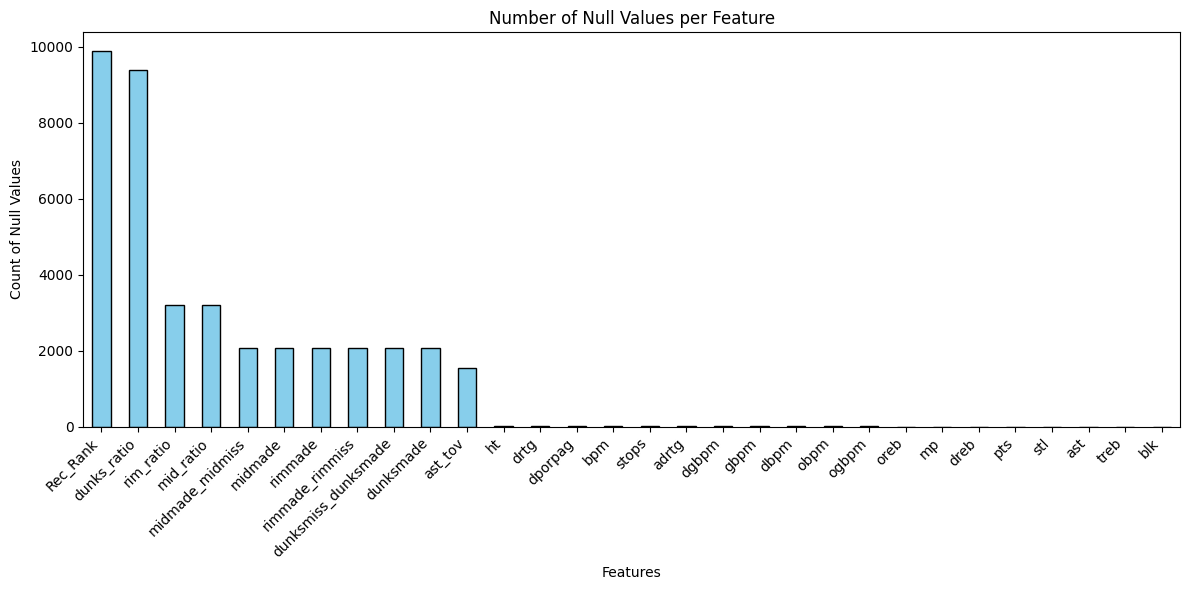

In [23]:
null_counts = train.isnull().sum().sort_values(ascending=False)
# Filter only features with missing values
null_counts = null_counts[null_counts > 0]
# Plot
plt.figure(figsize=(12, 6))
null_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Null Values per Feature')
plt.xlabel('Features')
plt.ylabel('Count of Null Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This cell visualizes the number of missing values for each feature in the training dataset.

- 11 columns have large amount of null values which will be dealt in the cleaning dataset stage.
- and 19 columns has few number of null values which can be removed 

- Next we will check for duplicates


In [24]:
# Check for duplicate rows
duplicate_rows = train[train.duplicated()]

# Display the number of duplicates
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

# Optionally, display the duplicates
duplicate_rows.head()



Number of duplicate rows: 2462


,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
12312,Liberty,BSth,14,1.5,54.6,34.8,18.8,27.93,14.2,26.8,...,-1.070620,0.1111,0.2778,0.3889,0.0556,0.1667,0.0000,0.2778,bace233f-cb91-4518-876f-66099be5ad37,0.0
12313,Cincinnati,BE,31,53.7,103.7,19.5,45.0,48.54,6.6,9.9,...,-0.384077,1.2903,1.8710,3.1613,1.3871,0.4516,0.1613,7.2903,e9370cf9-f64f-4666-b905-b041e2ca111c,0.0
12314,Ball St.,MAC,23,26.3,72.5,16.8,25.0,34.57,4.6,8.7,...,-0.579843,0.5652,1.0435,1.6087,1.0000,0.2609,0.1304,2.2609,07b7b849-1636-40ba-8418-9998c66a9d4c,0.0
12315,Prairie View A&M,SWAC,25,28.7,85.1,15.6,39.3,45.57,2.4,9.0,...,-0.044470,0.2800,1.0000,1.2800,1.2000,0.5200,0.0000,2.4400,bab9e93e-51bd-4fac-b45b-ed96b0dfee43,0.0
12316,Baylor,B12,14,2.2,93.2,31.6,45.0,54.35,16.2,9.9,...,-1.024930,0.2857,0.2143,0.5000,0.0714,0.0000,0.1429,1.0714,ed351de6-505e-4eef-a087-12948eefd100,0.0


This cell checks for duplicate rows in the training dataset.

- there are 2462 duplicate values which will be removed in the cleaning stage

In [25]:
# <Student to fill this section>
Explore_dataset_explanations = """

### Dataset Analysis

- Numerical Features:  
  The dataset contains 56 numerical columns, representing various player statistics and performance metrics. 
  These features are likely to be important for modeling and will require further analysis for missing values, outliers, and distribution.

- Categorical Features:  
  There are 6 categorical columns. One notable issue is the `'ht'` (height) column, which should be numerical but is currently stored as a date format.
    This will need to be converted to a proper numerical representation during feature engineering.

    
- Irrelevant Columns:  
  It appears that the `'yr'` and `'type'` columns contain only a single unique value each, 
  so they will not provide useful information for the model and can be removed during data cleaning.

- Data Quality Issues:  
  - Null Values:  
    - 11 columns have a large number of missing values. These columns will need to be addressed in the data cleaning stage, either by imputation or removal if the missingness is too high.
    - 19 columns have a small number of missing values, which can be removed or imputed with minimal impact on the dataset.
  - Duplicates:  
    - There are 2,462 duplicate rows in the dataset. These duplicates will be removed during data cleaning to ensure data integrity and prevent bias in model training.

- Feature Engineering Needs:  
  - The `'ht'` column requires conversion from its current format to a usable numerical value (e.g., total inches or centimeters).
  

- Overall:  
  The dataset is rich in both numerical and categorical features but requires significant cleaning and preprocessing. 
  Addressing missing values, duplicates, and incorrect data types is essential before proceeding to modeling. 
  Proper feature engineering will further enhance the predictive power of the dataset.

"""

In [26]:
# Do not modify this code
print_tile(size="h3", key='Explore_dataset_explanations', value=Explore_dataset_explanations)

### C.2 Define Target variable

In [27]:
# <Student to fill this section>
target= train["drafted"]

In [28]:
target.unique()

array([0., 1.])

- It has just 2 unique values.

In [29]:
# <Student to fill this section>
target_definition_explanations = """
Explain the rationale on the definition of the target variable according to your business use case.
The target variable is Drafted which gives a value of 0 or 1, indicating the selection of the player. 
The value equal to 1 representing strong chance of the player to get in the team. 
- Players use this to know their standing against others and how much they need to improve.
- commentators use this to fuel richer narratives backed by data quatifying their speech.
- fans able to match chances and rank players and decide on the comptence of the match.

"""

In [30]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [31]:
# <Student to fill this section>

target_name = 'drafted'

### C.4 Explore Target variable

In [32]:
target.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: drafted, dtype: float64

In [33]:
# <Student to fill this section>
target.describe()

count    14774.000000
mean         0.007987
std          0.089015
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: drafted, dtype: float64

-  we can see target column has 14774 rows.
- It has maximum value 1 
- It has minimum value 0
- it has mean close to 0.008 which suggest that there are alot more values equal to 0 than 1.

In [34]:
target.info()

<class 'pandas.core.series.Series'>
RangeIndex: 14774 entries, 0 to 14773
Series name: drafted
Non-Null Count  Dtype  
--------------  -----  
14774 non-null  float64
dtypes: float64(1)
memory usage: 115.6 KB


- There are no Null values as non null count meet the rangeindex entries count


In [35]:
target.value_counts()

drafted
0.0    14656
1.0      118
Name: count, dtype: int64

In [36]:

# Count drafted vs not drafted
counts = train['drafted'].value_counts()
labels = ['Not Selected', 'Selected']
colors = ['red', 'green']

# Create interactive donut chart
fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=counts,
    hole=0.5,
    marker=dict(colors=colors),
    hoverinfo='label+percent+value',
    textinfo='label+percent'
)])

fig.update_layout(
    title_text='Interactive Donut Chart: Drafted vs Not Drafted Players',
    showlegend=True
)

fig.show()


This cell visualizes the distribution of the target variable (drafted vs not drafted) using an interactive donut chart.

- We can see the data is highly biased towards not getting selected 
- We have only 0.799 % of getting selected data points 
- We have 99.2% of gettting Not Selected data points

In [37]:
# <Student to fill this section>
target_distribution_explanations = """
**Target Variable Analysis:**

- Definition:  
  The target variable is `drafted`, a binary indicator (1 = player drafted to NBA, 0 = not drafted).

- Distribution:  
  - Out of 14,774 samples, only 118 are positive (drafted), and 14,656 are negative (not drafted).
  - This means only ~0.8% of players are drafted, while ~99.2% are not.
  - The distribution is extremely imbalanced, as visualized in the donut chart above.

- No Missing Values:  
  - The target variable is complete, with no missing or null entries.

- Limitations & Issues:
  1. Severe Class Imbalance:  
     - The positive class (drafted) is extremely rare.  
     - Standard classifiers may be biased toward predicting the majority class (not drafted), leading to poor recall for the minority class.
     - Accuracy is a misleading metric in this context; a model predicting all 0s would still be >99% accurate.
     - Imbalanced data can cause underfitting for the minority class and may require special handling (e.g., resampling, class weighting, anomaly detection approaches).

  2. Potential for Overfitting:  
     - With so few positive samples, models may overfit to noise in the minority class.
     - Cross-validation splits must be stratified to ensure representation of both classes.

  


"""

In [38]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `Pts`

In [39]:
# <Student to fill this section>
feature_of_interest1 = train['pts']
print(feature_of_interest1.head(5))
feature_of_interest1.describe()

0    9.6538
1    2.0000
2    0.5000
3    7.7500
4    0.5714
Name: pts, dtype: float64


count    14773.000000
mean         3.662676
std          3.623175
min          0.000000
25%          1.000000
50%          2.448300
75%          5.363600
max         27.375000
Name: pts, dtype: float64

- The maximum value is 27.375 
- The minimum value is 0
- The mean is 3.662 suggesting most values are close to score of 3.6
- 75 % of observations donot cross score of 5.37 

In [40]:
feature_of_interest1.info()

<class 'pandas.core.series.Series'>
RangeIndex: 14774 entries, 0 to 14773
Series name: pts
Non-Null Count  Dtype  
--------------  -----  
14773 non-null  float64
dtypes: float64(1)
memory usage: 115.6 KB


- It has one Null Value
- we can also see that the data type is of float and is right for the column 

In [41]:
train[feature_of_interest1.isnull()]

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
11327,Montana,BSky,28,20.7,95.9,21.7,60.0,55.66,12.0,15.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,499d4d12-c8c3-47d2-865f-42ca13393cc7,0.0


In [42]:
feature_of_interest1.value_counts()

pts
0.0000     1182
1.0000      305
0.5000      209
2.0000      160
0.6667      144
           ... 
8.0400        1
13.4545       1
23.6970       1
0.7826        1
15.5882       1
Name: count, Length: 3453, dtype: int64

- The feature has 3453 unique values
- count corresponding to 0 is significant higher

In [43]:
# Different values for drafted with feaure_of_interest1 value == 0
train[feature_of_interest1==0].drafted.value_counts()

drafted
0.0    1182
Name: count, dtype: int64

- as suspected all the players with zero pts score are not drafted

In [44]:
# Different values for drafted with feaure_of_interest1 value >5
train[feature_of_interest1>5].drafted.value_counts()

drafted
0.0    3865
1.0     115
Name: count, dtype: int64

- 115 out of 118 drafted players have pts score greater than 5 ( almost top 25% players).
- this suggest this column is highly important for determining drafting.

Text(0.5, 1.0, 'Scatter Plot: Points vs Drafted')

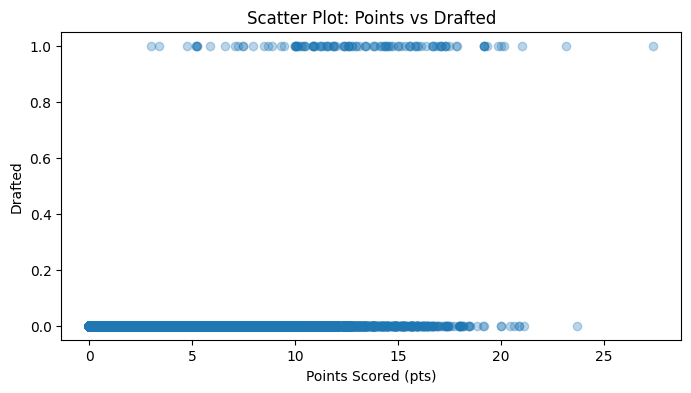

In [45]:

plt.figure(figsize=(8, 4))
plt.scatter(train['pts'], train['drafted'], alpha=0.3)
plt.xlabel('Points Scored (pts)')
plt.ylabel('Drafted')
plt.title('Scatter Plot: Points vs Drafted')

This cell creates a scatter plot to visualize the relationship between points scored ('pts') and the likelihood of being drafted.

- this graph clearly shows that pts value greater than 5 corresponds to high chances of getting drafted

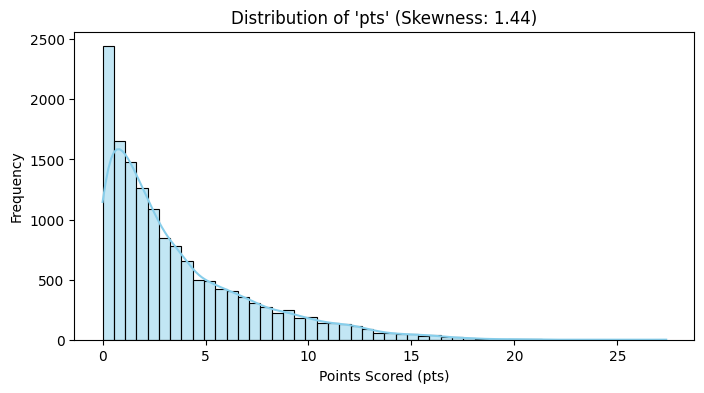

In [46]:
plt.figure(figsize=(8, 4))
sns.histplot(train['pts'], bins=50, kde=True, color='skyblue')
plt.title(f"Distribution of 'pts' (Skewness: {train['pts'].skew():.2f})")
plt.xlabel('Points Scored (pts)')
plt.ylabel('Frequency')
plt.show()

This cell plots the distribution of the 'pts' feature to examine its skewness and spread.

- the column is right skewed making it difficult for models to train and become easily biased.

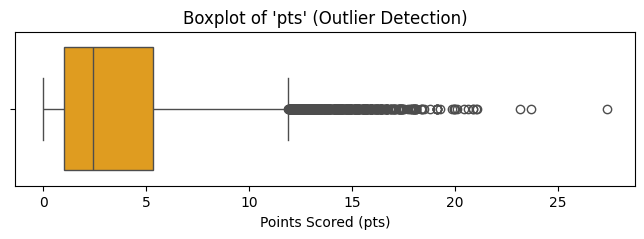

In [47]:
# Visualize outliers in the 'pts' column using a boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=train['pts'], color='orange')
plt.title("Boxplot of 'pts' (Outlier Detection)")
plt.xlabel('Points Scored (pts)')   
plt.show()

This cell visualizes outliers in the 'pts' column using a boxplot.

- there are so outliers but since we have highly favoured category, these outliers may be biased towards just majority class
- let us see

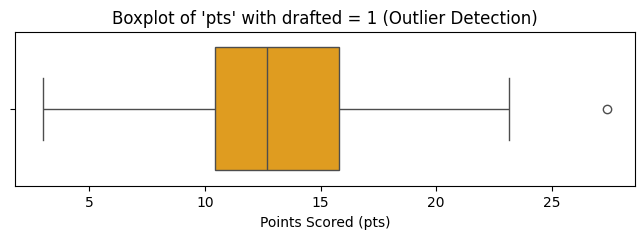

In [48]:
# Visualize outliers in the 'pts' column using a boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=train[train['drafted']==1].pts, color='orange')
plt.title("Boxplot of 'pts' with drafted = 1 (Outlier Detection)")
plt.xlabel('Points Scored (pts)')   
plt.show()

This cell shows a boxplot of 'pts' for players who were drafted (drafted = 1) to analyze outliers in this group.

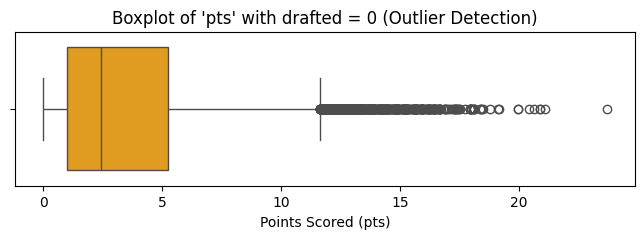

In [49]:
# Visualize outliers in the 'pts' column using a boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=train[train['drafted']==0].pts, color='orange')
plt.title("Boxplot of 'pts' with drafted = 0 (Outlier Detection)")
plt.xlabel('Points Scored (pts)')   
plt.show()

This cell shows a boxplot of 'pts' for players who were not drafted (drafted = 0) to analyze outliers in this group.

- on more precise outlier detection within each group we found that drafted = 0 has majority of the outliers 
    - this might be due to high bias data as we have high number of data points with drafted = 0

In [50]:
# <Student to fill this section>
feature_1_insights = """
provide a detailed analysis on the selected feature, its distribution, limitations, issues, ...


Distribution & Summary:
- The values range from 0 to 27.375, with a mean of 3.662.
- The distribution is right-skewed: most players score low points, and only a few achieve high scores.
- 75% of players have a `pts` value below 5.37, indicating that high scorers are rare.
- There is one missing value in the column, which should be addressed during data cleaning.
- The feature has 3453 unique values, showing a wide spread of scoring ability.
- A significant number of players have a score of 0, and none of these players were drafted.

Relationship with Target:
- Nearly all drafted players (115 out of 118) have a `pts` value greater than 5, suggesting a strong association between high scoring and being drafted.
- The scatter plot and value counts confirm that higher `pts` values are highly predictive of being drafted.

Limitations & Issues:
- Class Imbalance: The vast majority of players are not drafted, and most have low `pts` values. This imbalance can bias models and make it difficult to learn patterns for the minority (drafted) class.
- Outliers: The presence of very high `pts` values (outliers) may affect model performance and should be examined.
- **Missing Value: The single missing value can be imputed or handled out during preprocessing.
- Skewness: The right-skewed distribution may require transformation (e.g., log transformation) to improve model performance.
- Zero Inflation: Many players have a score of 0, which may reflect players who did not play or had limited opportunities, potentially introducing bias.

"""

In [51]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `Min_per` 

In [52]:
# <Student to fill this section>

In [53]:
feature_of_interest2 = train['Min_per']
print(feature_of_interest2.head(5))
feature_of_interest2.describe()

0    52.6
1     0.8
2     0.6
3    59.2
4    13.7
Name: Min_per, dtype: float64


count    14774.000000
mean        25.870123
std         23.639878
min          0.000000
25%          4.200000
50%         19.600000
75%         42.900000
max         94.300000
Name: Min_per, dtype: float64

- It has minimum value of 0 % played indicating the player never had chance or the his data was not recorded
- it has a maximum value of 94.3 %, this seems to be extremely high suggesting 1 guy carried the team.
- It has mean of 25.87 % indicating average time, his could be wrong as there are players with 0 % which can reduce the mean.
- Almost 75% people lies below 42.9 % time

In [54]:
feature_of_interest2.info()

<class 'pandas.core.series.Series'>
RangeIndex: 14774 entries, 0 to 14773
Series name: Min_per
Non-Null Count  Dtype  
--------------  -----  
14774 non-null  float64
dtypes: float64(1)
memory usage: 115.6 KB


- It has no Null values 
- we can also see that the data type is float and is correct for this column

In [55]:
feature_of_interest2.value_counts().sort_index(ascending=False)

Min_per
94.3      1
94.1      1
93.5      1
92.7      1
92.6      2
       ... 
0.4     178
0.3     217
0.2     286
0.1     258
0.0       5
Name: count, Length: 887, dtype: int64

- There are 887 unique values
- There are significant number of high values indicating immense skill difference in team

In [56]:

fig = px.histogram(train, x='Min_per', nbins=30, color_discrete_sequence=['lightgreen'])
fig.update_layout(
    title="Interactive Histogram of 'Min_per'",
    xaxis_title='Min_per (%)',
    yaxis_title='Frequency',
    bargap=0.05
)
fig.show()

This cell plots the distribution of the 'Min_per' feature to examine how much time players spent on the court.

- Many players have a Min_per value greater than 50%, indicating they participated in more than half of their team's total playing time, which suggests a high level of skill and importance to the team.

In [57]:
feature_of_interest2[feature_of_interest2>50]

0        52.6
3        59.2
11       59.2
14       58.4
18       53.0
         ... 
14752    55.6
14753    80.5
14762    61.9
14764    85.2
14771    84.7
Name: Min_per, Length: 2754, dtype: float64

- There are 2754 players with `Min_per` greater than 50, which is a significant portion of the dataset 

In [58]:
# Show players with Min_per > 50 and drafted == 1
train[(feature_of_interest2 > 50) & (train['drafted'] == 1)]

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
210,UCLA,P10,35,67.6,107.2,20.5,50.4,53.15,6.0,11.8,...,3.43319,1.2571,2.5143,3.7714,3.6857,1.5714,0.5143,8.4571,99eee70f-3af1-4563-84ab-389ef31cbbaf,1.0
212,USC,P10,35,82.8,108.2,22.3,53.1,55.51,9.3,11.6,...,1.44019,2.4000,3.3429,5.7429,1.4571,0.8857,0.3714,13.8571,4b2a8933-fb89-4e8e-a0a3-87a46ceb67d5,1.0
878,Memphis,CUSA,37,72.2,101.8,33.0,48.9,52.92,5.0,15.3,...,5.26382,1.2703,4.0811,5.3514,3.8649,2.0811,0.7838,17.0811,c78f1624-6bc7-4a8f-ba28-8cc4009f8e8b,1.0
1240,Ohio St.,B10,33,50.3,106.2,23.2,63.8,62.88,11.6,17.1,...,1.43677,1.6667,3.0000,4.6667,0.2727,0.4848,1.1212,8.8485,af62d5c3-073b-4ce7-bfac-c88688dbd62f,1.0
1367,Kansas,B12,36,68.3,113.7,21.7,55.5,59.10,5.2,11.5,...,2.47754,1.1944,3.1667,4.3611,1.4722,1.5000,0.5000,13.4167,9578f51f-3992-4aa6-827b-54d1a902dd59,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14172,Kentucky,SEC,37,84.0,114.1,22.8,51.6,57.87,3.2,10.0,...,3.04908,0.8919,3.2432,4.1351,5.1081,1.6486,0.4865,14.3784,342e2570-f770-411a-872e-ef60c9d71b95,1.0
14286,Kentucky,SEC,24,57.5,109.0,18.2,59.0,58.26,10.4,22.3,...,7.13561,2.7083,6.7500,9.4583,1.5833,2.0833,4.4167,10.4583,77658b9e-b471-4993-9392-147708b08a2f,1.0
14368,Duke,ACC,39,84.2,121.8,19.9,48.9,57.49,1.8,9.9,...,2.78366,0.4872,3.0256,3.5128,5.5641,1.5128,0.0769,11.8205,53e4b535-7362-4fe4-b793-33f56051c487,1.0
14611,Villanova,BE,40,69.7,121.0,17.9,57.3,58.77,9.9,23.0,...,2.22098,2.2500,5.7750,8.0250,0.7500,0.6500,1.4750,10.8500,efae6434-b18e-4742-8f83-7db3cca5c8d7,1.0


- we can see 100 out of the 118 drafted have min_pr >50 suggesting that this column is important for training

Text(0.5, 1.0, 'Scatter Plot: Min_per vs Drafted')

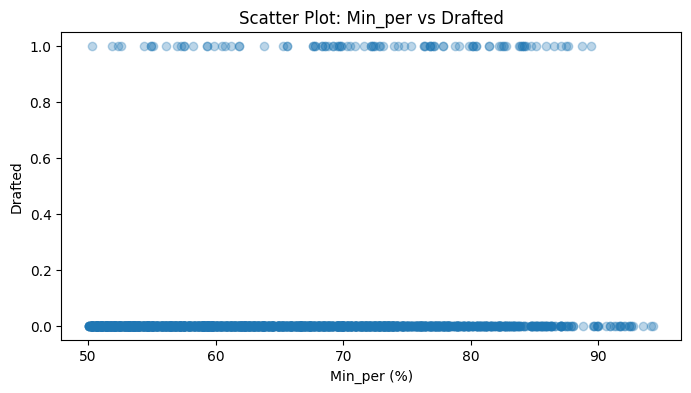

In [59]:

plt.figure(figsize=(8, 4))
plt.scatter(feature_of_interest2[feature_of_interest2>50], train[feature_of_interest2>50].drafted, alpha=0.3)
plt.xlabel('Min_per (%)')
plt.ylabel('Drafted')
plt.title('Scatter Plot: Min_per vs Drafted')

This cell creates a scatter plot to visualize the relationship between 'Min_per' (percentage of team minutes played) and the likelihood of being drafted.

In [60]:
# <Student to fill this section>
feature_2_insights = """
Distribution & Summary:
- The `Min_per` feature represents the percentage of total team minutes that a player participated in during the season.
- The values range from a minimum of 0% (players who never played or whose data was not recorded) to a maximum of 94.3% 
(indicating a player who was almost always on the court).
- The mean is 25.87%, but this is likely skewed lower by the presence of many players with 0% playing time.
- The 75th percentile is 42.9%, meaning that only a quarter of players played more than about 43% of their team's minutes.
- There are 887 unique values, showing a wide spread in playing time across players.
- No missing values are present in this feature.

Key Insights:
- A significant number of players have high `Min_per` values, indicating that some players are much more central to their teams 
than others.
- Many players (2,754) have `Min_per` greater than 50%, meaning they played more than half of their team's total minutes.
 This suggests these players are likely key contributors.
- Among drafted players, 100 out of 118 have `Min_per` above 50%, highlighting a strong relationship between playing time and 
likelihood of being drafted.

Limitations & Issues:
- Zero Inflation: The presence of many players with 0% playing time may reflect bench players, injured players, or data entry
 issues. This can skew summary statistics and may not be informative for modeling.
- Right Skew: The distribution is right-skewed, with most players having lower playing time and a minority playing very
 high percentages. This may require transformation or careful handling in modeling.
- Potential Bias: Players with high `Min_per` are more likely to be noticed and thus drafted, but this may also reflect 
team strategy rather than individual skill alone.
"""

In [61]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `OBPM`


In [62]:
# <Student to fill this section>

In [63]:
feature_of_interest3 = train['obpm']
print(feature_of_interest3.head(5))
feature_of_interest3.describe()

0     2.627860
1   -13.028600
2    -9.079290
3    -0.339201
4    -9.045760
Name: obpm, dtype: float64


count    14769.000000
mean        -3.121418
std          5.769338
min        -68.542000
25%         -5.253410
50%         -2.565850
75%         -0.160565
max        161.995000
Name: obpm, dtype: float64

- we can see that the mean is -3.12 which is slightly below zero suggesting that On average player contributes slightly below league average offensively
- The lowest OBPM is -68.542, indicating very poor offensive contribution for the minima data point
- The 50% = -2.56 indicate that half of the players are lie in the less offensive playstyle
- The negetive 75 percentage suggest that most of players are not offensive than the league average
- 	The highest obpm is 161.995, which is a very high jump from most of the contributors, indicating an elite offensive contributor 

In [64]:
feature_of_interest3.info()

<class 'pandas.core.series.Series'>
RangeIndex: 14774 entries, 0 to 14773
Series name: obpm
Non-Null Count  Dtype  
--------------  -----  
14769 non-null  float64
dtypes: float64(1)
memory usage: 115.6 KB


- We can see there are 5 null values as there are only 1479 non null entries out of 14774 entries in total
-  We can also see that the data type is correct and is of float .

In [65]:
# Interactive histogram for feature_of_interest3 (obpm)
fig = px.histogram(
    train,
    x='obpm',
    nbins=50,
    title="Interactive Histogram of 'obpm' (Offensive Box Plus/Minus)",
    color_discrete_sequence=['#636EFA']
)
fig.update_layout(
    xaxis_title='OBPM (Offensive Box Plus/Minus)',
    yaxis_title='Frequency',
    bargap=0.05
)
fig.show()

This cell plots the distribution of the 'obpm' (Offensive Box Plus/Minus) feature to examine its shape and spread.

- The column form a bell curve with few outliers on both of the extreme sides.
- we can see most of the players are near 0 ie. the league average offensively
- but majority of players are below zero pulling down mean value


In [66]:
len(feature_of_interest3[feature_of_interest3> 0])

3486

- there are around 3500 players that play more aggressively than the league average

In [67]:
train[feature_of_interest3 > 0]['drafted'].value_counts()

drafted
0.0    3378
1.0     108
Name: count, dtype: int64

- out of 118 drafted players 108 are have OBPM score greater than league averge 
- this means this column is important for determining the player drafting

In [68]:
# Assuming 'feature_of_interest3' and 'train' are DataFrames
fig = px.scatter(x=train[feature_of_interest3 > 0]['obpm'], y=train[feature_of_interest3 > 0]['drafted'])
fig.update_layout(title='Relationship between feature_of_interest3 and Drafted',
                  xaxis_title='feature_of_interest3 (above 0)',
                  yaxis_title='Drafted')
fig.show()

This cell creates a scatter plot to visualize the relationship between 'obpm' (Offensive Box Plus/Minus) and the likelihood of being drafted.

- we can see that there are lots of values in not drafted with obpm greater than zero as well 
- this could make the model struggle

In [69]:
# <Student to fill this section>
feature_n_insights = """
provide a detailed analysis on the selected feature, its distribution, limitations, issues, ...

Feature: OBPM (Offensive Box Plus/Minus)

Distribution & Summary:
- The OBPM feature is approximately bell-shaped (normal-like), but with a mean of -3.12, indicating most players contribute slightly below league average offensively.
- The median (50th percentile) is -2.56, and the 75th percentile is also negative, confirming that the majority of players are below average in offensive impact.
- The minimum value is extremely low (-68.54), and the maximum is extremely high (161.99), showing the presence of significant outliers on both ends.
- Most players cluster near 0, but the distribution is slightly left-skewed and hence the negative mean.
- There are 5 missing values in this column, which should be addressed during data cleaning.

Relationship with Target:
- 3486 players have OBPM > 0 (above league average offensively).
- Of the 118 drafted players, 108 have OBPM > 0, indicating a strong association between high OBPM and being drafted.
- However, many undrafted players also have OBPM > 0, so while a high OBPM increases the chance of being drafted, it is not a guarantee.

Limitations & Issues:
- Outliers: The extreme minimum and maximum values may distort model training and should be handled (e.g., capping, transformation).
- Missing Values: The presence of missing values (5 out of ~14,774) needs to be addressed.
- Overlap: There is considerable overlap between drafted and undrafted players for OBPM > 0, which may reduce the feature's discriminative power.
- Skewness: The negative skew (mean < median) suggests most players are below average, which may bias models if not handled.
- Interpretability: While OBPM is a strong indicator, it should be used alongside other features for robust predictions.

Conclusion:
- OBPM is a valuable feature for predicting draft status, especially for identifying top offensive contributors.
- Its predictive power is limited by overlap with undrafted players and the presence of outliers and missing values.
- Proper preprocessing (handling missing values, outliers, and possible transformation) is needed before using this feature in modeling.

"""

In [70]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

### C.n Explore Feature of Interest `\<put feature name here\>`

> You can add more cells related to other feeatures in this section

---
## D. Feature Selection


### D.1 Approach "Chi-Square Test "



we will use statistical tests chi-square for categorical features  to evaluate the individual relationship between each feature and the target variable. This helps to quickly filter out features with little or no predictive power.


In [71]:
final_features = []

In [72]:
categorical_features.head()

,team,conf,yr,ht,type,player_id
0,Pacific,BW,Fr,11-May,all,681edf6e-41cb-4fd1-ba91-da573e063fbc
1,Mississippi,SEC,Fr,2-Jun,all,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4
2,Stephen F. Austin,Slnd,Fr,1-Jun,all,ca0d8700-807d-4fce-a7a9-63922d1981e6
3,Virginia,ACC,Fr,1-Jun,all,01285c6b-bc71-4fa8-941a-28cf3976a117
4,Elon,SC,Fr,2-Jun,all,a962c41c-55ff-461e-8585-db32e4fa0580


In [73]:
temp=categorical_features.copy() # create a copy of categorical features for further processing

In [74]:
for col in temp.columns:
    le= LabelEncoder()
    temp[col] = le.fit_transform(temp[col])
temp.head()

,team,conf,yr,ht,type,player_id
0,225,10,0,8,0,4925
1,175,29,0,10,0,2548
2,281,31,0,3,0,9607
3,332,1,0,3,0,61
4,81,28,0,10,0,8079


In [75]:
X=temp.drop(columns=['ht',       # dropped ht coz it is supposed to be numerical column
                     'yr',      # dropped yr coz it has only one unique value as discussed in data exploration
                     'type',    # dropped type coz it has only one unique value as discussed in data exploration
                     'player_id' # dropped player_id coz it is id column
                     ],axis=1) 

y=train['drafted']

- dropped ht coz it is supposed to be numerical column
- dropped yr coz it has only one unique value as discussed in data exploration
- dropped type coz it has only one unique value as discussed in data exploration
- dropped player_id coz it is id column

In [76]:
chi_score= chi2(X,y)

In [77]:
chi_score

(array([218.62882546,   7.97152796]), array([1.80084312e-49, 4.75188113e-03]))

Text(0.5, 1.0, 'Chi-Squared Test Results for Categorical Features')

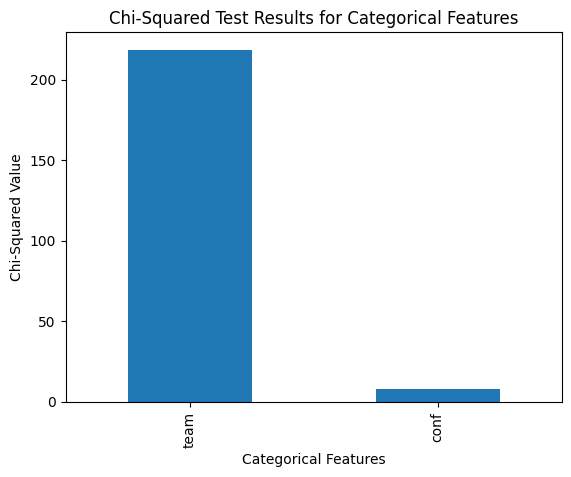

In [78]:
chi_values = pd.Series(chi_score[0], index=X.columns, name='Chi-Squared Value').sort_values(ascending=False)
ax = chi_values.plot.bar()
ax.set_xlabel("Categorical Features")
ax.set_ylabel("Chi-Squared Value")
ax.set_title("Chi-Squared Test Results for Categorical Features")

- High chi sq value is means good association
- The 'team' feature appears to have a strong association with whether a player is drafted.
- The 'conf' column, on the other hand, does not seem to be significantly related and may not be useful for modeling.

In [79]:
final_features.append('team')

In [80]:
# <Student to fill this section>
feature_selection_1_insights = """
provide an explanation on why you use this approach for feature selection and describe its results

The Chi-Square test is a well-established statistical method for evaluating the association between categorical features 
and a categorical target variable. By applying this test, we can quantitatively assess which categorical features are most relevant for predicting 
the target, allowing us to filter out features with little or no predictive power early in the process.

In this analysis, we excluded columns such as 'ht' (which should be treated as numerical), 'yr' and 'type' 
(both with only one unique value and thus not informative), and 'player_id' (an identifier, not a predictive feature). 

The results showed that the 'team' feature has a strong association with the target variable (drafted), 
while features like 'conf' do not show significant relevance and may be excluded from further modeling. 
This approach ensures that only meaningful categorical predictors are retained for the next steps.
"""

In [81]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "ANOVA"


In [82]:
temp=train.copy() # create a copy of train for further processing of ht column for anova

In [83]:
# <Student to fill this section>
def ht_str_to_cm(ht_str):
    """
    Convert 'ht' column from date-like string (e.g., '1-Jun') to centimeters.
    Assumes format: '<inches>-<MonthAbbr>' where MonthAbbr maps to feet.
    Example: '1-Jun' -> 6'1'' -> 6 feet 1 inch.
    """
    # Map month abbreviations to feet
    month_to_feet = {
        'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
        'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
    }
    try:
        # Split the string
        parts = ht_str.split('-')
        if len(parts) != 2:
            return np.nan
        inches = int(parts[0])
        month = parts[1].strip().title()
        feet = month_to_feet.get(month)
        if feet is None:
            return np.nan
        total_inches = feet * 12 + inches
        cm = round(total_inches * 2.54, 1)
        return cm
    except Exception:
        return np.nan

# Apply conversion to the 'ht' column
numerical_features['ht'] = temp['ht'].apply(ht_str_to_cm)

# Preview the conversion
print(numerical_features[ 'ht'].head())


0    180.3
1    188.0
2    185.4
3    185.4
4    188.0
Name: ht, dtype: float64


- Converted the ht column into the correct numerical column (cm) 

In [84]:
numerical_features.head()

,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,AST_per,TO_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,drafted,ht
0,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,17.6,24.7,...,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,0.0,180.3
1,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,0.0,19.6,...,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,0.0,188.0
2,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,0.0,40.3,...,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,0.0,185.4
3,28,59.2,88.2,21.7,46.2,47.25,1.5,9.7,25.2,27.4,...,1.45913,0.3214,2.0357,2.3571,3.0000,1.2857,0.0714,7.7500,0.0,185.4
4,21,13.7,47.5,15.0,26.2,26.20,5.8,2.3,10.2,47.1,...,-3.75694,0.3810,0.1429,0.5238,0.4286,0.1905,0.0000,0.5714,0.0,188.0


In [85]:


# Select only numerical columns (excluding the target)
numerical_cols = numerical_features.columns.drop('drafted')

anova_results = []
selected_features = []

alpha = 0.05  # significance level

for col in numerical_cols:
    group0 = numerical_features[numerical_features['drafted'] == 0][col].dropna()
    group1 = numerical_features[numerical_features['drafted'] == 1][col].dropna()
    f_stat, p_val = f_oneway(group0, group1)
    anova_results.append({
        'feature': col,
        'F-test ratio': f_stat,
        'p-value': p_val
    })
    if p_val < alpha:
        selected_features.append(col)

# Create DataFrame of results
anova_df = pd.DataFrame(anova_results).sort_values('F-test ratio', ascending=False)

# Print selected features
print("Best features selected by ANOVA (p-value < 0.05):")
print(selected_features )
print()
# not selected features
print("Features not selected by ANOVA (p-value >= 0.05):")
print(anova_df[anova_df['p-value'] >= alpha][['feature', 'F-test ratio', 'p-value']])


Best features selected by ANOVA (p-value < 0.05):
['GP', 'Min_per', 'Ortg', 'usg', 'eFG', 'TS_per', 'DRB_per', 'AST_per', 'TO_per', 'FTM', 'FTA', 'FT_per', 'twoPM', 'twoPA', 'twoP_per', 'TPM', 'TPA', 'TP_per', 'blk_per', 'porpag', 'adjoe', 'year', 'Rec_Rank', 'ast_tov', 'rimmade', 'rimmade_rimmiss', 'midmade', 'midmade_midmiss', 'rim_ratio', 'mid_ratio', 'dunksmade', 'dunksmiss_dunksmade', 'dunks_ratio', 'drtg', 'adrtg', 'dporpag', 'stops', 'bpm', 'obpm', 'dbpm', 'gbpm', 'mp', 'ogbpm', 'dgbpm', 'oreb', 'dreb', 'treb', 'ast', 'stl', 'blk', 'pts', 'ht']

Features not selected by ANOVA (p-value >= 0.05):
    feature  F-test ratio   p-value
24      pfr      2.826222  0.092757
6   ORB_per      2.600582  0.106846
21      ftr      2.082546  0.149013
20  stl_per      1.972347  0.160220


- Anova tells us whether there are statistically significant difference betweent the means of two or more groups.
    - F test->  A higher F-value indicates a greater difference between the group means relative to the variation within the groups. This suggests
                 the feature is more likely to be useful for distinguishing between classes (e.g., drafted vs. not drafted).
    - p-value-> If the p-value is less than the chosen significance level (commonly α = 0.05), we reject the null hypothesis that the group means
                 are equal. This means the feature is statistically significant and likely relevant for predicting the target.

- Results
    - Features with p-value < 0.05 are considered to have a significant difference between groups and are good candidates for modeling.
    - Features with p-value ≥ 0.05 do not show a significant difference and may be less useful for prediction.
   - hence we Select all columns which p < 0.05 and discard others [pfr,orb_pr,ftr,stl_per] with p≥ 0.05.


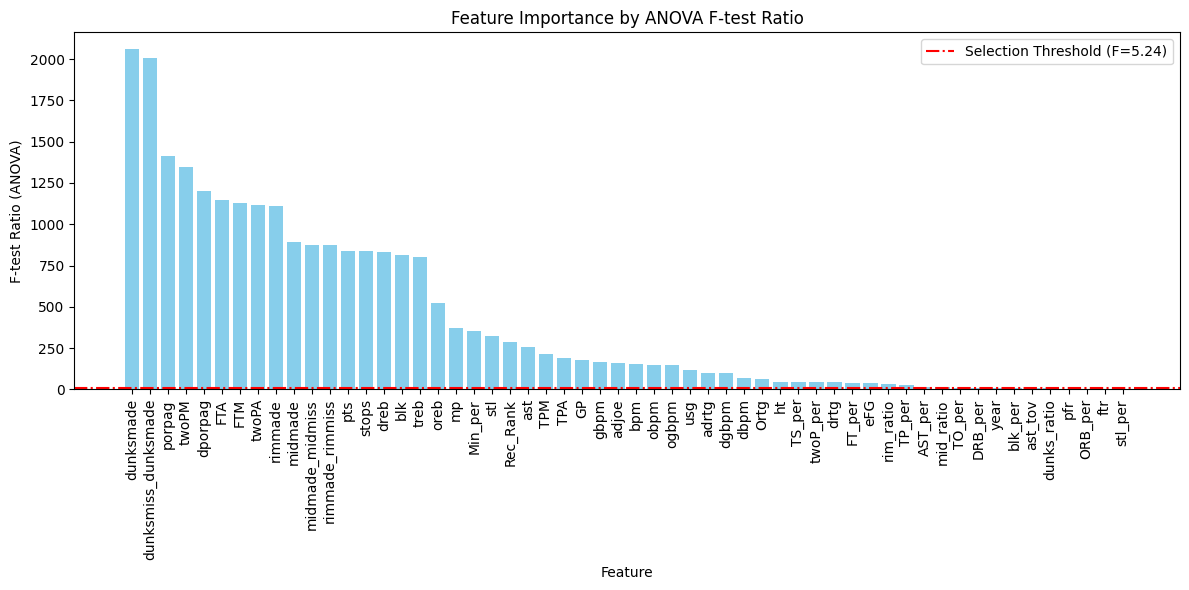

In [86]:


# anova_df should already be created from previous ANOVA code
# It contains columns: 'feature', 'F-test ratio', 'p-value' 

plt.figure(figsize=(12, 6))
bars = plt.bar(anova_df['feature'], anova_df['F-test ratio'], color='skyblue')
plt.xlabel('Feature')
plt.ylabel('F-test Ratio (ANOVA)')
plt.title('Feature Importance by ANOVA F-test Ratio')
plt.xticks(rotation=90)
plt.tight_layout()

# Mark the threshold line for significance (alpha = 0.05)
# Find the minimum F-test ratio among selected features (p-value < alpha)
alpha = 0.05
if (anova_df['p-value'] < alpha).any():
    threshold = anova_df[anova_df['p-value'] < alpha]['F-test ratio'].min()
    plt.axhline(y=threshold, color='red', linestyle='-.', label=f'Selection Threshold (F={threshold:.2f})')
    plt.legend()

plt.show()

This cell visualizes the F-test ratios from the ANOVA feature selection to highlight the most important numerical features.

In [87]:
# selected features
print("Features selected by ANOVA (p-value < 0.05):")
print(anova_df[anova_df['p-value'] < alpha][['feature', 'F-test ratio', 'p-value']])

Features selected by ANOVA (p-value < 0.05):
                feature  F-test ratio        p-value
34            dunksmade   2059.546046   0.000000e+00
35  dunksmiss_dunksmade   2006.874562   0.000000e+00
22               porpag   1415.549610  6.501310e-296
13                twoPM   1344.984461  6.867271e-282
39              dporpag   1203.278414  1.549390e-253
11                  FTA   1148.389060  1.724145e-242
10                  FTM   1127.347186  3.038746e-238
14                twoPA   1116.569544  4.568354e-236
28              rimmade   1109.873552  2.230211e-233
30              midmade    894.376767  5.807679e-190
31      midmade_midmiss    876.398761  2.615230e-186
29      rimmade_rimmiss    873.105355  1.222735e-185
54                  pts    836.356127  6.239361e-179
40                stops    835.999425  7.410209e-179
49                 dreb    834.777901  1.317912e-178
53                  blk    811.619671  7.743609e-174
50                 treb    799.223870  2.783789e-171
4

- we can see dunksmade, dunksmiss_dunksmade, porpag column have the highest level of assocication with the drafted column as per ANOVA.
- 

In [88]:

for i in selected_features:
    final_features.append(i)


final_features=set(final_features)  # Convert to set to avoid duplicates
final_features = list(final_features)  # Convert back to list for consistency
len(final_features)

53

- need to make sure the list consist of no duplicate values

In [89]:
# <Student to fill this section>
feature_selection_2_insights = """

provide an explanation on why you use this approach for feature selection and describe its results

ANOVA/f-test for numerical features was used to evaluate the individual relationship between each feature and the target variable.

We used the ANOVA (Analysis of Variance) test for feature selection because of its statistical method to determine whether there
are significant differences in the means of a numerical feature across two or more groups—in this case, drafted vs. not drafted players.
ANOVA provides two key outputs: the F-test ratio (which measures the variance between groups relative to the variance within groups) and 
the p-value (which indicates the probability that the observed differences are due to chance).

By selecting features with p-value < 0.05, we ensure that only those features that show a statistically significant difference between drafted 
and non-drafted players are retained for modeling. This helps reduce noise and improve model performance by focusing on the most relevant predictors.

The results showed that features like 'dunksmade', 'dunksmiss_dunksmade', and 'porpag' have the highest association with the target variable, 
indicating they are strong predictors of draft status. Features with p-value ≥ 0.05, such as 'pfr', 'orb_pr', 'ftr', and 'stl_per', were excluded 
as they do not provide significant discriminatory power.

This approach ensures that the final feature set is both statistically justified and relevant for the prediction task, reducing the risk of 
overfitting and improving interpretability.
"""

In [90]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.n Approach "\<describe_approach_here\>"

> You can add more cells related to other approaches in this section

## D.z Final Selection of Features

In [91]:
# <Student to fill this section>

features_list = final_features # we dont create .copy(), because we will keep reference
features_list

['FTA',
 'ast',
 'obpm',
 'porpag',
 'year',
 'rim_ratio',
 'mp',
 'AST_per',
 'DRB_per',
 'rimmade',
 'dporpag',
 'twoP_per',
 'ht',
 'blk',
 'TPM',
 'Ortg',
 'TS_per',
 'TP_per',
 'usg',
 'bpm',
 'midmade',
 'FT_per',
 'Min_per',
 'dunks_ratio',
 'midmade_midmiss',
 'dunksmade',
 'team',
 'eFG',
 'ogbpm',
 'twoPA',
 'pts',
 'Rec_Rank',
 'stops',
 'rimmade_rimmiss',
 'adrtg',
 'oreb',
 'ast_tov',
 'twoPM',
 'adjoe',
 'dgbpm',
 'mid_ratio',
 'dunksmiss_dunksmade',
 'dreb',
 'stl',
 'drtg',
 'blk_per',
 'GP',
 'gbpm',
 'treb',
 'TO_per',
 'TPA',
 'dbpm',
 'FTM']

In [92]:
# <Student to fill this section>
feature_selection_explanations = """
The selected features were chosen based on their strong statistical association with the target variable (drafted) 
using both Chi-Square tests for categorical variables and ANOVA for numerical variables.

These features demonstrated significant differences between drafted and non-drafted players, 
making them the most relevant predictors for the model. 

"""

In [93]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Cleaning "Removing the duplicates"

In [94]:
# <Student to fill this section>

This cell checks for duplicate rows in the training dataset as part of the data cleaning process.

In [95]:
# Check for duplicate rows
num_duplicates = train.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")


Number of duplicate rows: 2462


In [96]:

# Remove duplicate rows
train = train.drop_duplicates()
print(f"Shape after removing duplicates: {train.shape}")

Shape after removing duplicates: (12312, 62)


In [97]:
# Check for duplicate rows
num_duplicates = train.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")


Number of duplicate rows: 0


In [98]:
# <Student to fill this section>
data_cleaning_1_explanations = """
It is important to remove duplicate rows to ensure data quality and integrity.
Duplicate entries can bias the analysis and model training by over-representing certain data points, 
leading to inaccurate or misleading results.
Removing duplicates ensures that each observation contributes equally,
improves model generalization, and prevents inflated performance metrics. This step is essential for building a reliable 
and trustworthy predictive model.
"""

In [99]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Cleaning "Removing the column with only one unique value"

In [100]:
# <Student to fill this section>

In [101]:
# Check how many columns has more than 1 unique value
train.nunique().sort_values(ascending=True)

yr             1
type           1
drafted        2
year          10
ht            32
           ...  
obpm       12256
porpag     12257
gbpm       12260
dgbpm      12262
ogbpm      12265
Length: 62, dtype: int64

In [102]:
'yr' in selected_features

False

In [103]:
'type' in selected_features


False

we dont have to worry about this column since it is not in the selected features list

we dont have to worry about this column since it is not in the selected features list

- These columns do not provide any useful information to the model during training and should therefore be removed.

In [104]:
# Check how many columns has more than 1 unique value
train[selected_features].nunique().sort_values(ascending=True)

year                      10
ht                        32
GP                        41
dunksmade                 72
dunksmiss_dunksmade       73
midmade                   88
TPM                       99
rimmade                  146
dunks_ratio              151
FTM                      174
twoPM                    193
midmade_midmiss          201
blk_per                  210
rimmade_rimmiss          212
FTA                      226
TPA                      235
twoPA                    351
TP_per                   398
usg                      408
DRB_per                  464
AST_per                  466
Rec_Rank                 500
twoP_per                 515
eFG                      558
FT_per                   577
TO_per                   650
blk                      694
stl                      723
Min_per                  887
mid_ratio                968
oreb                    1052
rim_ratio               1287
Ortg                    1332
ast                     1412
dreb          

In [105]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Provide some explanations on why you believe it is important to fix this issue and its impacts

It is important to remove columns with only one unique value because they do not provide any meaningful information or variability for 
the model to learn from. Keeping such columns can add unnecessary noise, increase computational cost, and potentially lead to overfitting 
without improving model performance. 
"""

In [106]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Cleaning "Null Values"

In [107]:
# <Student to fill this section>

In [108]:
train.isnull().sum().sort_values(ascending=False)

Rec_Rank           8240
dunks_ratio        7831
rim_ratio          2672
mid_ratio          2665
midmade_midmiss    1720
                   ... 
GP                    0
team                  0
type                  0
player_id             0
drafted               0
Length: 62, dtype: int64

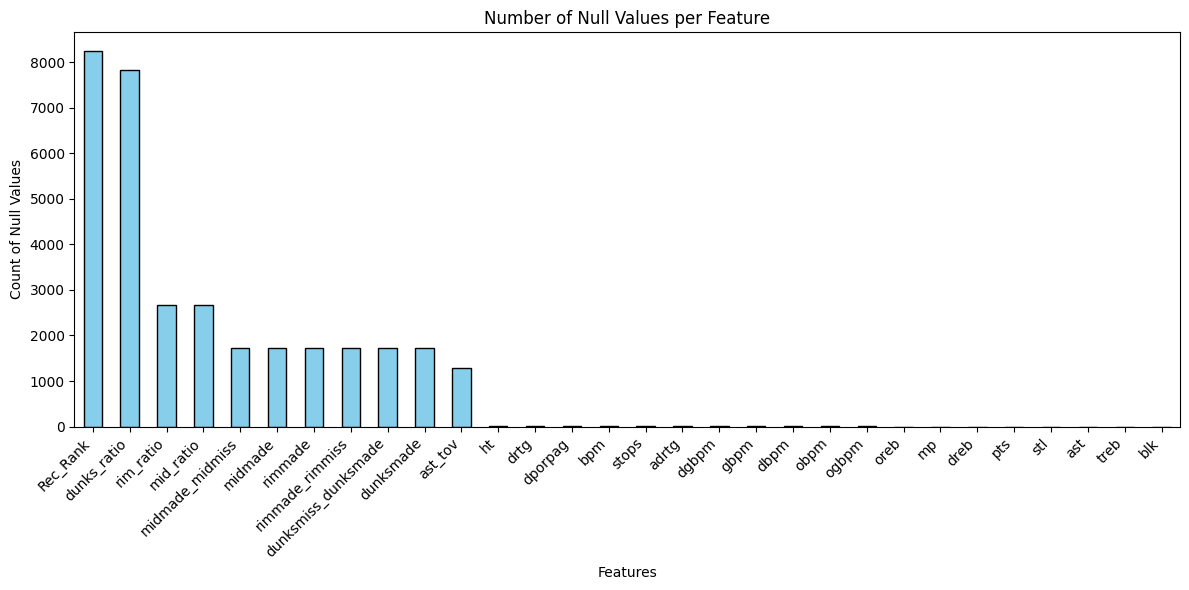

In [109]:
null_counts = train.isnull().sum().sort_values(ascending=False)
# Filter only features with missing values
null_counts = null_counts[null_counts > 0]
# Plot
plt.figure(figsize=(12, 6))
null_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Null Values per Feature')
plt.xlabel('Features')
plt.ylabel('Count of Null Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This cell visualizes the number of missing values for each feature in the training dataset to guide null value handling.

- On visualizing we came to know that 19 of the columns have very few null values. 

In [110]:
train.ht.isnull().sum()

np.int64(7)

- the highest number of null values amoung the small number of null value group of columns is 8 fr ht column 
- we will use this information to determine how many null values exist cumulatively in the small number of null values group column


In [111]:
# Find columns with less than 10 null values
few_null_cols = train.columns[(train.isnull().sum() < 10)&(train.isnull().sum() > 0)]
len(few_null_cols)
# Get all rows where any of these columns have a null value
rows_with_nulls = train[train[few_null_cols].isnull().any(axis=1)]
# # Display or process these rows as needed
len(rows_with_nulls)

11

- we just need to remove 11 entires to get rid of the group of small number of null value columns

In [112]:
# Remove rows where any column with less than 10 nulls has a null value
few_null_cols = train.columns[(train.isnull().sum() < 10) & (train.isnull().sum() > 0)]
train = train.dropna(subset=few_null_cols)

In [113]:
# Find columns with less than 10 null values
few_null_cols = train.columns[(train.isnull().sum() < 10)&(train.isnull().sum() > 0)]
len(few_null_cols)
# Get all rows where any of these columns have a null value
rows_with_nulls = train[train[few_null_cols].isnull().any(axis=1)]
# # Display or process these rows as needed
len(rows_with_nulls)

0

- now lets deal with the large number of null values column group

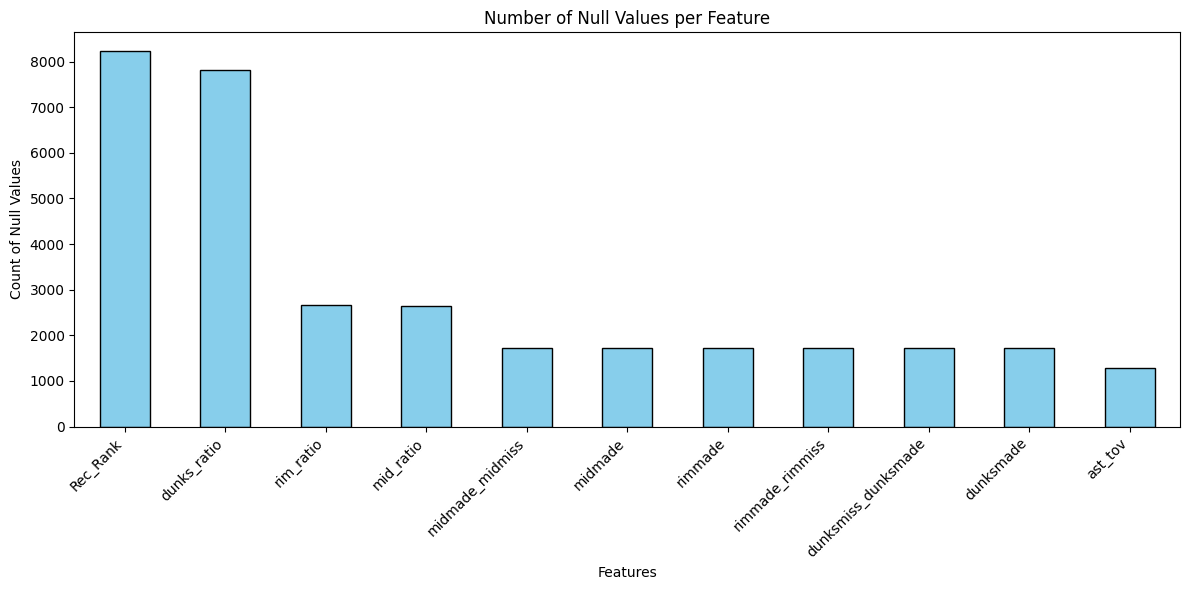

In [114]:
null_counts = train.isnull().sum().sort_values(ascending=False)
# Filter only features with missing values
null_counts = null_counts[null_counts > 0]
# Plot
plt.figure(figsize=(12, 6))
null_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Null Values per Feature')
plt.xlabel('Features')
plt.ylabel('Count of Null Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This cell again visualizes missing values for each feature after some null value handling steps, to check progress.

- we start from the column with most null values 

In [115]:
"Rec_Rank" in final_features

True

- it is part of final_features

In [116]:
train.Rec_Rank.isnull().sum()

np.int64(8229)

In [117]:
train.Rec_Rank.value_counts()

Rec_Rank
88.6    12
79.0    12
60.6    12
89.8    12
50.4    12
        ..
11.4     4
3.8      4
9.0      4
2.8      3
2.4      3
Name: count, Length: 500, dtype: int64

- Rec_Rank,Recruiting rank i.e. what the player was ranked as a recruit coming out of high school
- The `Rec_Rank` column contains 9,872 null values and only 500 unique values. 
Since this ranking was assigned during high school graduation and may depend on various unknown factors, Even though it is in final_features list it is not considered usefull due to so many null values. Therefore, we will drop this column from the dataset.

In [118]:
final_features.remove('Rec_Rank')


Dropping the column from the selected features

In [119]:
"dunks_ratio" in final_features

True

- it is present in final_features column

In [120]:
train.dunks_ratio.isnull().sum()

np.int64(7820)

In [121]:
train.dunks_ratio.value_counts().sort_index(ascending=False)

dunks_ratio
1.0000    2539
0.9853       1
0.9836       1
0.9804       1
0.9796       1
          ... 
0.4000       8
0.3333      31
0.2500       3
0.2000       2
0.0000     236
Name: count, Length: 151, dtype: int64

- lets see what might be causing inf value
- if we see at the formula denominator has train['dunksmiss_dunksmade'] - train['dunksmade'] meaning these values could be same

In [122]:
# List all entries where dunksmade equals dunksmiss_dunksmade
equal_dunks = train[train['dunksmade'] == train['dunksmiss_dunksmade']].dunksmade.value_counts()
print(equal_dunks)

dunksmade
0.0     6105
1.0     1023
2.0      472
3.0      309
4.0      196
5.0      119
6.0       83
7.0       73
8.0       59
9.0       35
10.0      31
11.0      24
12.0      15
15.0      14
13.0      14
14.0      13
16.0      11
18.0       8
20.0       5
19.0       4
17.0       4
21.0       3
25.0       3
24.0       3
22.0       3
26.0       2
30.0       2
31.0       2
52.0       1
29.0       1
23.0       1
28.0       1
34.0       1
48.0       1
35.0       1
56.0       1
27.0       1
Name: count, dtype: int64


- so i think it would be fair if we just assign 1 as denominator to these entries assuming each player recorded missed one dunk.

In [123]:
# Calculate 'dunks_ratio' as the ratio between dunks made and dunks missed, handling zero division
denominator = train['dunksmiss_dunksmade'] - train['dunksmade']
train['dunks_ratio'] = np.where(denominator != 0, train['dunksmade'] / denominator, train['dunksmade'])

In [124]:
train.dunks_ratio.isnull().sum()

np.int64(1715)

In [125]:
train.dunksmade.isnull().sum()

np.int64(1715)

In [126]:
train.dunksmiss_dunksmade.isnull().sum()

np.int64(1715)

- Lets see if we have zero values in both dunksmiss_dunksmade and dunksmade column 


In [127]:
train[(train.dunksmade==0)&(train.dunksmiss_dunksmade==0)].drafted.value_counts()

drafted
0.0    6101
1.0       4
Name: count, dtype: int64

- this implies that their score were never recorded same as missing values meaning we can treat missing values as zero as well


In [128]:
train[train['dunks_ratio'].isnull()].drafted.value_counts()

drafted
0.0    1711
1.0       4
Name: count, dtype: int64

In [129]:
train[train['dunksmiss_dunksmade'].isnull()].drafted.value_counts()

drafted
0.0    1711
1.0       4
Name: count, dtype: int64

In [130]:
train[train['dunksmade'].isnull()].drafted.value_counts()

drafted
0.0    1711
1.0       4
Name: count, dtype: int64

- we can see all the three columns contribution to drafted is around 4.2 percent only (5/118*100)
- so we can fill all of the null values as zero in all three columns

In [131]:
train['dunksmade'].fillna(0, inplace=True)
train['dunksmiss_dunksmade'].fillna(0, inplace=True)
train['dunks_ratio'].fillna(0, inplace=True)
train.dunks_ratio.isnull().sum()

np.int64(0)

This cell fills missing values in the dunks-related columns with zero, based on the assumption that missing means no attempts.

In [132]:
train.dunksmade.isnull().sum() == train.dunksmiss_dunksmade.isnull().sum() == train.dunks_ratio.isnull().sum()


np.True_

- there were 9375 null values and we used dunksmade and dunksmiss_dunksmade coulumns to reduce the null value to 2069
- using proper reasoning and assumptions, we filled all the null values


In [133]:
train['ast_tov'].isnull().sum()

np.int64(1276)

In [134]:
# Calculate missing values in 'ast_tov' using assists (ast) and estimated turnovers (TOV)
# TOV is not directly available, but can be estimated from TO_per, FGA, and FTA

# Calculate FGA (Field Goal Attempts)
train['FGA'] = train['twoPA'] + train['TPA']
test['FGA'] = test['twoPA'] + test['TPA']
# Estimate TOV (Turnovers) using TO_per formula:
# TO_per = 100 * TOV / (FGA + 0.44 * FTA + TOV)
# Rearranged: TOV = (TO_per / (100 - TO_per)) * (FGA + 0.44 * FTA)
train['TOV_est'] = (train['TO_per'] / (100 - train['TO_per'])) * (train['FGA'] + 0.44 * train['FTA'])
test['TOV_est'] = (test['TO_per'] / (100 - test['TO_per'])) * (test['FGA'] + 0.44 * test['FTA'])

# Fill missing ast_tov values where possible, set to zero if division is not possible
for idx, row in train[train['ast_tov'].isnull()].iterrows():
    tov = row['TOV_est']
    ast = row['ast']
    if pd.notnull(tov) and tov != 0:
        train.at[idx, 'ast_tov'] = ast / tov
    else:
        train.at[idx, 'ast_tov'] = 0

This cell estimates turnovers and fills missing values in the 'ast_tov' column using available data and logical assumptions.

- we choose to fill null values equal to zero  where ever the formula is not valid based on the column distribution.

In [135]:
train['ast_tov'].isnull().sum()

np.int64(0)

In [136]:
# Fill missing values for rim_ratio, mid_ratio, rimmade, rimmade_rimmiss, midmade, midmade_midmiss

# 1. Fill missing rimmade, rimmade_rimmiss, midmade, midmade_midmiss with 0 (if missing means no attempts)
for col in ['rimmade', 'rimmade_rimmiss', 'midmade', 'midmade_midmiss']:
    train[col].fillna(0, inplace=True)

# 2. Fill rim_ratio and mid_ratio using the formulas, set to 0 if denominator is 0
# rim_ratio = rimmade / (rimmade_rimmiss - rimmade)
denom_rim = train['rimmade_rimmiss'] - train['rimmade']
train['rim_ratio'] = np.where(denom_rim != 0, train['rimmade'] / denom_rim, 0)

# mid_ratio = midmade / (midmade_midmiss - midmade)
denom_mid = train['midmade_midmiss'] - train['midmade']
train['mid_ratio'] = np.where(denom_mid != 0, train['midmade'] / denom_mid, 0)

This cell fills missing values for rim and mid-range shot columns and calculates the corresponding ratios, handling zero denominators.

- Reasoning : According to the metadata, rimmade and midmade represent the number of shots made at or near the rim and from mid-range, respectively. Their corresponding rimmade_rimmiss and midmade_midmiss columns represent the total attempts (made + missed) for those shot types.
- Missing = No attempts: If these columns are missing, it is reasonable to assume the player did not attempt such shots, so filling with 0 is appropriate.
- Ratio calculation: The ratios (rim_ratio, mid_ratio) are defined as made / (attempts - made). If the denominator is zero (no misses), the ratio is set to 0 to avoid division by zero and because a player with no misses or attempts should not have a meaningful ratio.

In [137]:
train.isnull().sum().sort_values(ascending=False)

Rec_Rank     8229
TOV_est        83
GP              0
team            0
Ortg            0
             ... 
stl             0
pts             0
player_id       0
drafted         0
FGA             0
Length: 64, dtype: int64

In [138]:
'TOV_est' in final_features

False

- the only TOV_est column  with null values is not in the final features list so we will simply leave it as it will be dropped during training of the model.

In [139]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Provide some explanations on why you believe it is important to fix this issue and its impacts

Fixing null values is crucial for ensuring data quality and reliable model performance. Columns with a small 
number of null values can be handled by removing the affected rows, which minimally impacts the dataset. 
However, columns with a large number of nulls, like `Rec_Rank`, provide little useful information and can 
introduce bias or instability if retained, so they should be dropped.

For features where missing values indicate no attempts (e.g., `dunksmade`, `dunksmiss_dunksmade`, `rimmade`, 
`midmade`), filling nulls with zero is logical and preserves the integrity of the data. For ratio columns, 
setting the value to zero when the denominator is zero avoids invalid or infinite values.

If null values are not addressed, models may misinterpret missingness as meaningful, leading to inaccurate 
predictions, reduced generalizability, and unreliable business insights. Properly handling nulls ensures the 
model learns from complete, consistent, and representative data, ultimately improving its effectiveness and 
trustworthiness for decision-making.

"""

In [140]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "ht"


In [141]:
train.ht.head()

0    11-May
1     2-Jun
2     1-Jun
3     1-Jun
4     2-Jun
Name: ht, dtype: object

In [142]:

# <Student to fill this section>
def ht_str_to_cm(ht_str):
    """
    Convert 'ht' column from date-like string (e.g., '1-Jun') to centimeters.
    Assumes format: '<inches>-<MonthAbbr>' where MonthAbbr maps to feet.
    Example: '1-Jun' -> 6'1'' -> 6 feet 1 inch.
    """
    # Map month abbreviations to feet
    month_to_feet = {
        'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
        'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
    }
    try:
        # Split the string
        parts = ht_str.split('-')
        if len(parts) != 2:
            return np.nan
        inches = int(parts[0])
        month = parts[1].strip().title()
        feet = month_to_feet.get(month)
        if feet is None:
            return np.nan
        total_inches = feet * 12 + inches
        cm = round(total_inches * 2.54, 1)
        return cm
    except Exception:
        return np.nan

# Apply conversion to the 'ht' column
train['ht'] = train['ht'].apply(ht_str_to_cm)
# Applying to test dataset as well
test['ht'] = test['ht'].apply(ht_str_to_cm) 

# Preview the conversion
train['ht'].head()


0    180.3
1    188.0
2    185.4
3    185.4
4    188.0
Name: ht, dtype: float64

In [143]:
test.ht.head()

0    198.1
1    195.6
2    205.7
3    200.7
4    208.3
Name: ht, dtype: float64

In [144]:
train.ht.isnull().sum()

np.int64(897)

In [145]:
# Fill null values in 'ht' column with the mean of the column
train['ht'].fillna(train['ht'].mean(), inplace=True)
mean_ht = train['ht'].mean()
train.ht.isnull().sum()

np.int64(0)

This cell fills missing values in the 'ht' (height) column with the mean height value.

Filling missing values in test set 

In [146]:
test['ht'].fillna(mean_ht, inplace=True)

In [147]:
test.ht.isnull().sum()

np.int64(0)

- we also found some null values in test.ht column so we fill mean_ht value in those null values as well


- Converted the ht column into the correct numerical column (cm) 

In [148]:
# <Student to fill this section>
feature_engineering_1_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts

The height column was interpret wrongly as dates in acutal the numbers represent is height in feet and inches 
(since Americans use imperial units for height) but somehow the csv has stored them as date.

It is important to convert the 'ht' column into a numerical feature (centimeters). Using a numerical format allows
the model to interpret and utilize this information effectively. 

we found some missing values in the data so we filled them with the mean height.

Note : we also found some null values in test.ht column so we fill mean_ht value in those null values as well


"""

In [149]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "Points Per Minute"




In [150]:
# <Student to fill this section>


# Assign zero if Min_per is zero, otherwise compute points per minute
train['points_per_min'] = np.where(
    train['Min_per'] == 0,
    0,
    train['pts'] / train['Min_per']
)
train['points_per_min'].head()

0    0.183532
1    2.500000
2    0.833333
3    0.130912
4    0.041708
Name: points_per_min, dtype: float64

This cell creates a new feature, 'points_per_min', representing points scored per minute played.

In [151]:
test['points_per_min'] = np.where(
    test['Min_per'] == 0,
    0,
    test['pts'] / test['Min_per']
)

In [152]:
train['points_per_min'].describe()

count    12301.000000
mean         0.301330
std          1.130312
min          0.000000
25%          0.094440
50%          0.134149
75%          0.194213
max         30.000000
Name: points_per_min, dtype: float64

- we can see 75th percentile of the values are below 1 
- we have an extreme maxima of 30
- we have mean of 0.3

In [153]:
train['points_per_min'].value_counts().sort_index(ascending=False)

points_per_min
30.000000      6
20.000000      9
15.000000      4
13.333333      1
11.666500      1
            ... 
0.014571       1
0.014519       1
0.014500       1
0.009917       1
0.000000     984
Name: count, Length: 9857, dtype: int64

In [154]:
train[train['drafted']==1]['points_per_min'].value_counts().sort_index(ascending=False)

points_per_min
2.439024    1
0.851439    1
0.366069    1
0.323464    1
0.312857    1
           ..
0.128677    1
0.125105    1
0.123157    1
0.120104    1
0.103813    1
Name: count, Length: 97, dtype: int64

In [155]:
train[train['points_per_min'] > 1]

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,treb,ast,stl,blk,pts,player_id,drafted,FGA,TOV_est,points_per_min
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0.0,6,1.462687,2.500000
15,Davidson,SC,4,1.3,120.3,28.6,70.0,70.00,0.0,5.9,...,0.2500,0.5000,0.0000,0.0000,3.5000,83a572a4-bcf6-4bc5-855a-2cf7871d48d0,0.0,10,2.755102,2.692308
59,Northern Iowa,MVC,1,0.5,73.5,20.4,33.3,33.33,0.0,0.0,...,0.0000,0.0000,0.0000,0.0000,2.0000,4a320a21-cbd8-4d6f-a4a9-63a916528bc4,0.0,3,0.000000,4.000000
70,Liberty,BSth,3,1.9,71.7,16.6,37.5,37.50,0.0,0.0,...,0.0000,0.0000,0.0000,0.6667,2.0000,130d05ce-ba15-40e1-9740-f6053650616c,0.0,8,1.411765,1.052632
88,Wisconsin,B10,4,0.4,208.8,20.5,100.0,100.00,0.0,0.0,...,0.0000,0.5000,0.0000,0.0000,0.5000,3dc97175-3c9c-41f9-baad-618a6a77fcc4,0.0,1,0.000000,1.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12290,St. Bonaventure,A10,6,0.9,123.0,13.8,100.0,100.00,0.0,18.9,...,0.3333,0.0000,0.0000,0.0000,1.0000,32b3a1eb-1c6e-43a6-ab18-16aba3dc7375,0.0,3,1.615385,1.111111
12291,St. Francis NY,NEC,5,0.6,200.0,5.3,100.0,100.00,0.0,17.7,...,0.2857,0.0000,0.0000,0.0000,0.7143,87f50f7c-56ea-4b79-8dda-07077db3671e,0.0,1,0.000000,1.190500
12296,San Diego,WCC,1,0.2,300.0,6.9,150.0,150.00,0.0,0.0,...,0.5000,0.0000,0.5000,0.5000,2.0000,c24fba2e-307e-45dc-9aa3-e7f93dcb7587,0.0,1,0.000000,10.000000
12297,San Diego,WCC,2,0.2,111.1,20.0,50.0,40.40,85.2,0.0,...,1.6667,0.0000,0.0000,0.0000,2.3333,45e470b4-c27d-48db-a74b-0df2655c098a,0.0,4,0.729195,11.666500


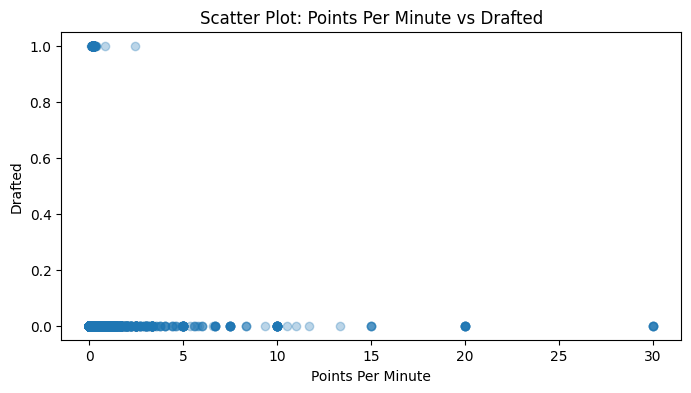

In [156]:
plt.figure(figsize=(8, 4))
plt.scatter(train['points_per_min'], train['drafted'], alpha=0.3)
plt.xlabel('Points Per Minute')
plt.ylabel('Drafted')
plt.title('Scatter Plot: Points Per Minute vs Drafted')
plt.show()

This cell creates a scatter plot to visualize the relationship between points per minute and the likelihood of being drafted.

- we can see that  most of the drafted players lie below 1.

In [157]:
train.points_per_min.isnull().sum()

np.int64(0)

In [158]:
final_features.append('points_per_min')


In [159]:
# <Student to fill this section>
feature_engineering_2_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts

The points_per_min is an important feature because it directly measures a player's efficiency and finishing ability near the basket.
High dunk conversion rates often indicate athleticism, skill, and the ability to capitalize on high-percentage scoring opportunities—traits 
valued by scouts and teams. Including this feature helps the model distinguish players who not only attempt dunks but also successfully complete
them, which can be a strong indicator of overall offensive effectiveness and potential for success at higher levels of competition. 
This can improve the model's ability to predict which players are more likely to be drafted, as efficient scorers are generally more attractive 
to professional teams
"""

In [160]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "Three point percentage"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [161]:
# Calculate three-point percentage, set to zero if denominator is zero
train['tp_pct'] = np.where(train['TPA'] != 0, train['TPM'] / train['TPA'], 0)
train['tp_pct'].head()

0    0.495413
1    0.000000
2    0.000000
3    0.314286
4    0.166667
Name: tp_pct, dtype: float64

In [162]:
test['tp_pct'] = np.where(test['TPA'] != 0, test['TPM'] / test['TPA'], 0)

In [163]:
train['tp_pct'].describe()

count    12301.000000
mean         0.205034
std          0.198383
min          0.000000
25%          0.000000
50%          0.230769
75%          0.335443
max          1.000000
Name: tp_pct, dtype: float64

- we can see that meain is 0.2
- we can see that 75 percentile is 0.33


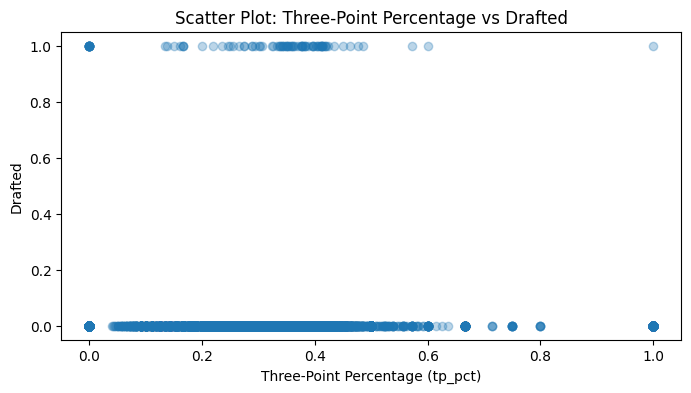

In [164]:
plt.figure(figsize=(8, 4))
plt.scatter(train['tp_pct'], train['drafted'], alpha=0.3)
plt.xlabel('Three-Point Percentage (tp_pct)')
plt.ylabel('Drafted')
plt.title('Scatter Plot: Three-Point Percentage vs Drafted')
plt.show()

This cell creates a scatter plot to visualize the relationship between three-point percentage and the likelihood of being drafted.

- we can see that most drafted players lies between 0.2 to 0.5 aproximately.

In [165]:
train.tp_pct.isnull().sum()

np.int64(0)

In [166]:
final_features.append('tp_pct')

In [167]:
# <Student to fill this section>
feature_engineering_n_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts

Creating the three-point percentage (`tp_pct`) feature is important because it captures a player's efficiency
in making three-point shots, which is a highly valued skill in modern basketball. Teams increasingly rely on 
players who can score from beyond the arc to stretch defenses and increase offensive versatility. By including
`tp_pct`, the model can better identify players with strong shooting abilities, which is often a key factor 
in draft decisions.
   
   """

In [168]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.n Fixing "\<describe_issue_here\>"

> You can add more cells related to new features in this section

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [169]:
# <Student to fill this section>

In [170]:
train_transformed = train.copy() # create a copy of train for further processing in later experiments

# 'features_list' contains the selected feature names and 'target_name' is defined
X = train[features_list]
y = train[target_name]

# First split: train+val and test (80%/20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: train and val (from 80%: 75% train, 25% val → 60%/20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (7380, 54), Validation shape: (2460, 54), Test shape: (2461, 54)


This cell splits the dataset into training, validation, and test sets using stratified sampling to preserve class balance.

In [171]:
# <Student to fill this section>
data_splitting_explanations = """
Provide some explanations on what is the best strategy to use for data splitting for this dataset

The best strategy for data splitting in this dataset is to use stratified splitting with three sets: 
training, validation, and test. Stratification ensures that the severe class imbalance (very few drafted
players) is preserved in all splits, preventing bias and ensuring reliable model evaluation. The 
approach is to use 60% for training, 20% for validation, and 20% for testing. This allows for robust model 
training, hyperparameter tuning, and unbiased final evaluation, while maintaining representative class 
distributions in each subset.
"""


In [172]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation " Encoding categorical features"

In [173]:
# <Student to fill this section>
X_train[features_list].select_dtypes(include=['object', 'category'])



,team
9413,Tennessee
1719,San Francisco
6067,Longwood
5119,Texas A&M
8108,Florida
...,...
618,Tulsa
12136,Maryland
2462,South Dakota
10795,Grambling St.


In [174]:
X_train['team'].nunique()

355

- It has 335 unique values so using one got encding wont be a good choice 

- While encoding test dataset we found out that test.team has 'North Alabama' value which is not present in train.team columns so we encoded it seperately

In [175]:
'North Alabama' in test.team.values

True

In [176]:
'North Alabama' in gg.team.values  # gg is the copy of train we made at starting of the notebook for comparision

False

In [177]:

le = LabelEncoder()
X_train['team'] = le.fit_transform(X_train['team'])

# Handle unseen labels in test set (e.g., 'North Alabama')
# Find teams in test not in train
unseen_teams = set(test['team'].unique()) - set(le.classes_)
if unseen_teams:
    # Add unseen teams to classes_
    le.classes_ = np.concatenate([le.classes_, list(unseen_teams)])



test['team'] = le.transform(test['team']) # transforming the test dataset 
train_transformed['team'] = le.transform(train_transformed['team']) # transforming the copy of train dataset we made at starting of the notebook for comparision

# To check the mapping:
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))


In [178]:
unseen_teams

{'Cal Baptist', 'Merrimack', 'North Alabama'}

- we found 3 names in test.team which are not included in the train.team

In [179]:
# Encode 'team' in X_val and X_test using the same LabelEncoder fitted on X_train
X_val['team'] = le.transform(X_val['team'])
X_test['team'] = le.transform(X_test['team'])

In [180]:
label_mapping

{'Abilene Christian': np.int64(0),
 'Air Force': np.int64(1),
 'Akron': np.int64(2),
 'Alabama': np.int64(3),
 'Alabama A&M': np.int64(4),
 'Alabama St.': np.int64(5),
 'Albany': np.int64(6),
 'Alcorn St.': np.int64(7),
 'American': np.int64(8),
 'Appalachian St.': np.int64(9),
 'Arizona': np.int64(10),
 'Arizona St.': np.int64(11),
 'Arkansas': np.int64(12),
 'Arkansas Little Rock': np.int64(13),
 'Arkansas Pine Bluff': np.int64(14),
 'Arkansas St.': np.int64(15),
 'Army': np.int64(16),
 'Auburn': np.int64(17),
 'Austin Peay': np.int64(18),
 'BYU': np.int64(19),
 'Ball St.': np.int64(20),
 'Baylor': np.int64(21),
 'Belmont': np.int64(22),
 'Bethune Cookman': np.int64(23),
 'Binghamton': np.int64(24),
 'Boise St.': np.int64(25),
 'Boston College': np.int64(26),
 'Boston University': np.int64(27),
 'Bowling Green': np.int64(28),
 'Bradley': np.int64(29),
 'Brown': np.int64(30),
 'Bryant': np.int64(31),
 'Bucknell': np.int64(32),
 'Buffalo': np.int64(33),
 'Butler': np.int64(34),
 'Cal P

Benefits of using label encoding:

- Simple and Fast: Converts categorical values to numeric codes quickly and efficiently.
- No Increase in Dimensionality: Unlike one-hot encoding, it does not create additional columns, keeping the dataset compact.
- Works Well for Tree-Based Models: Many tree-based algorithms (like Decision Trees, Random Forests, XGBoost) can handle label-encoded features without issues.

In [181]:
# <Student to fill this section>
data_transformation_1_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts

Label encoding is important for transforming categorical variables, such as 'team', into a numeric format 
that machine learning algorithms can process. This is especially crucial when the feature has a high number 
of unique categories (e.g., 335 teams), where one-hot encoding would create too many columns and increase 
dimensionality, leading to inefficiency and potential overfitting.

Note : we found 3 names in test.team which are not included in the train.team
so we encoded them  as well.

By using label encoding:
- The data remains compact and memory-efficient.
- It enables the use of powerful tree-based models, which can handle label-encoded features without assuming 
any ordinal relationship.
- It ensures that all information from the categorical variable is retained without exploding the feature space.

Overall, this transformation allows the model to utilize categorical information effectively while maintaining 
computational efficiency and model performance.
"""

In [182]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "Log Transformation"

In [183]:
# <Student to fill this section>

In [184]:
# Find names of right-skewed columns among selected features (skewness > 0.5)
right_skewed = []
for col in final_features:
    if float(X_train[col].dropna().skew()) > 0.5:
        right_skewed.append(col)
print("Right-skewed columns:", right_skewed)
len(right_skewed)

Right-skewed columns: ['FTA', 'ast', 'obpm', 'porpag', 'rim_ratio', 'mp', 'AST_per', 'DRB_per', 'rimmade', 'dporpag', 'blk', 'TPM', 'TP_per', 'bpm', 'midmade', 'Min_per', 'dunks_ratio', 'midmade_midmiss', 'dunksmade', 'twoPA', 'pts', 'stops', 'rimmade_rimmiss', 'oreb', 'ast_tov', 'twoPM', 'dgbpm', 'mid_ratio', 'dunksmiss_dunksmade', 'dreb', 'stl', 'blk_per', 'treb', 'TO_per', 'TPA', 'dbpm', 'FTM', 'points_per_min', 'tp_pct']


39

- we have 37 right skewed columns 
- we will be performing log transformation on these columns 

In [185]:
# Create a DataFrame of column names and their skewness values for selected features
skewness_data = []
for col in final_features:
    skew_val = X_train[col].dropna().skew()
    skewness_data.append({'feature': col, 'skewness': skew_val})

skewness_df = pd.DataFrame(skewness_data)
skewness_df

,feature,skewness
0,FTA,1.916892
1,ast,2.305005
2,obpm,1.701688
3,porpag,1.507092
4,year,0.010924
5,rim_ratio,2.016363
6,mp,0.659284
7,AST_per,3.222105
8,DRB_per,49.538398
9,rimmade,2.366784


In [186]:
print("Columns not needing log transformation:")
non_skewed_cols=set(final_features)  -set(right_skewed)
print(non_skewed_cols)



Columns not needing log transformation:
{'adjoe', 'ht', 'year', 'adrtg', 'Ortg', 'team', 'eFG', 'ogbpm', 'TS_per', 'drtg', 'GP', 'gbpm', 'usg', 'FT_per', 'twoP_per'}


- These columns need not to be transformed 


 Lets visualize the  5 right skewed columns

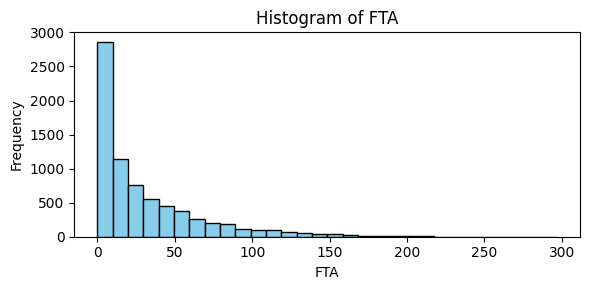

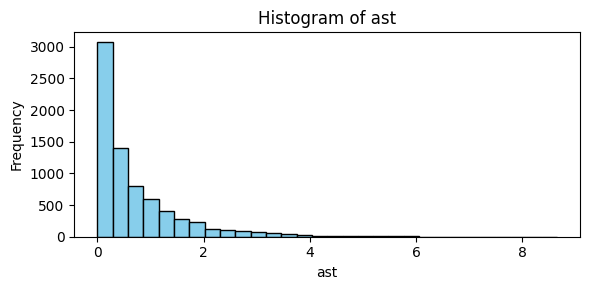

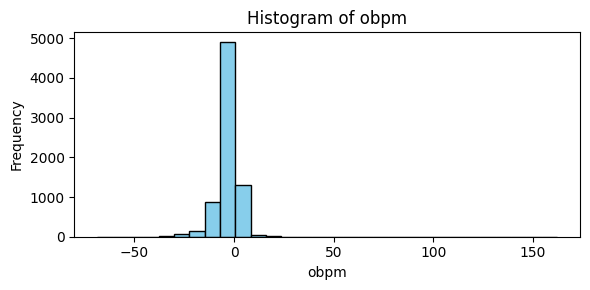

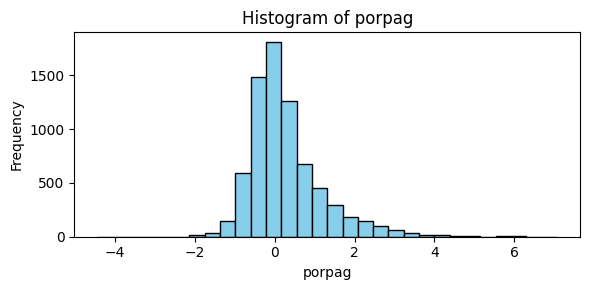

In [187]:
# <Student to fill this section>
# Plot histograms for only the first 5 right-skewed columns

for name in right_skewed[:4]:
    plt.figure(figsize=(6, 3))
    plt.hist(X_train[name].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {name}')
    plt.xlabel(name)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

This cell plots histograms for the first five right-skewed features before log transformation to visualize their distributions.

In [188]:
X_train[right_skewed].head()

,FTA,ast,obpm,porpag,rim_ratio,mp,AST_per,DRB_per,rimmade,dporpag,...,dreb,stl,blk_per,treb,TO_per,TPA,dbpm,FTM,points_per_min,tp_pct
9413,32,0.0625,-1.622770,0.375312,0.750000,12.1875,0.8,13.7,12.0,1.228330,...,1.6250,0.1562,8.0,3.1562,20.7,0,2.716270,21,0.057707,0.000000
1719,25,0.1250,-4.666300,-0.596967,1.500000,12.0417,2.1,10.0,9.0,0.847338,...,1.0000,0.1667,1.9,1.7917,33.8,0,-0.064408,16,0.079365,0.000000
6067,137,1.3226,-0.962747,1.765170,2.140000,32.5161,8.8,21.5,107.0,1.643320,...,5.9677,1.0968,3.3,8.4516,22.7,17,-0.701961,96,0.166468,0.235294
5119,2,0.6667,10.914000,0.416284,0.000000,1.0000,100.0,0.0,0.0,0.048510,...,0.0000,0.0000,0.0,0.0000,0.0,0,-15.299800,1,1.666500,0.000000
8108,55,0.6970,0.102805,1.118700,1.947368,19.0303,8.1,13.1,37.0,2.395690,...,1.9697,0.5152,2.4,2.7879,15.1,82,2.501580,35,0.136106,0.256098


In [189]:
# Log transform the right-skewed columns (add 1 to avoid log(0))
for col in right_skewed:
    X_train[col] = np.log1p(X_train[col]).fillna(0)

In [190]:
# Log transform the right-skewed columns (add 1 to avoid log(0)) in test dataset as well
for col in right_skewed:
    test[col] = np.log1p(test[col]).fillna(0)

In [191]:
for col in right_skewed:
    train_transformed[col] = np.log1p(train_transformed[col])

In [192]:
# Log transform the right-skewed columns (add 1 to avoid log(0))
for col in right_skewed:
    X_test[col] = np.log1p(X_test[col]).fillna(0)

In [193]:
# Log transform the right-skewed columns (add 1 to avoid log(0))
for col in right_skewed:
    X_val[col] = np.log1p(X_val[col]).fillna(0)

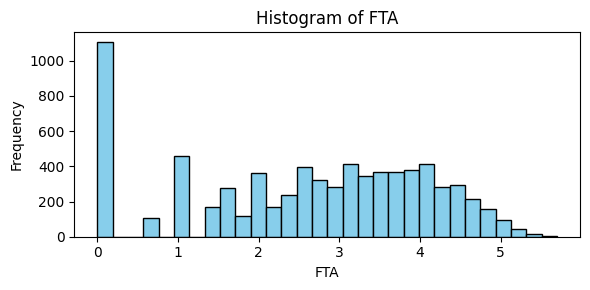

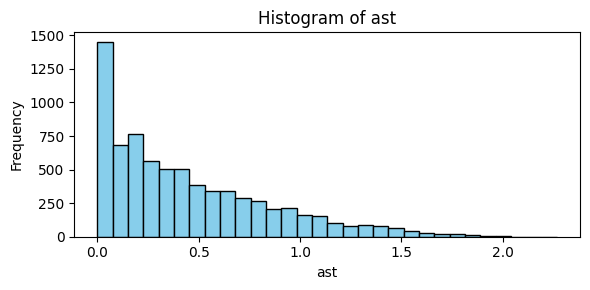

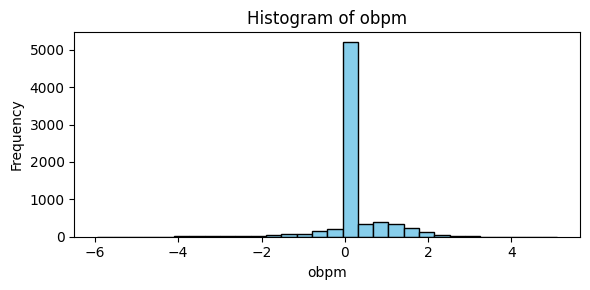

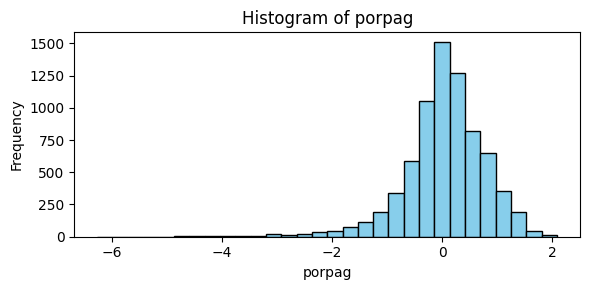

In [194]:
# <Student to fill this section>
# Plot histograms for only the first 5 right-skewed columns after transformation

for name in right_skewed[:4]:
    plt.figure(figsize=(6, 3))
    plt.hist(X_train[name].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {name}')
    plt.xlabel(name)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

This cell plots histograms for the first five right-skewed features after log transformation to show the effect of the transformation.

In [195]:
# Find names of right-skewed columns among selected features (skewness > 0.5)
right_skewed = []
for col in final_features:
    if float(X_train[col].dropna().skew()) > 0.5:
        right_skewed.append(col)
print("Right-skewed columns:", right_skewed)
len(right_skewed)

Right-skewed columns: ['ast', 'blk', 'dunks_ratio', 'dunksmade', 'oreb', 'mid_ratio', 'dunksmiss_dunksmade', 'stl', 'blk_per', 'points_per_min']


10

- we are now left with 9 right skewed columns with skewness greater than 0.5 but with reduced skewness than before 

In [196]:
X_train[right_skewed].head()

,ast,blk,dunks_ratio,dunksmade,oreb,mid_ratio,dunksmiss_dunksmade,stl,blk_per,points_per_min
9413,0.060625,0.677424,0.000000,0.000000,0.928693,0.587787,0.000000,0.145139,2.197225,0.056104
1719,0.117783,0.189214,0.693147,0.693147,0.583165,0.344840,0.693147,0.154179,1.064711,0.076373
6067,0.842687,0.770710,3.091042,3.091042,1.248152,0.516216,3.091042,0.740412,1.458615,0.153980
5119,0.510846,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.980767
8108,0.528862,0.332106,1.386294,2.944439,0.597847,0.441833,3.218876,0.415547,1.223775,0.127607


we dealt with right skewness it was important because it

- Reduce model accuracy: Skewed data can lead to less accurate predictions and unstable models.
- Impact feature importance: Skewness can distort relationships between features and the target, making it harder for the model to learn true patterns.


In [197]:
# <Student to fill this section>
data_transformation_2_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts

Log transformation of right-skewed features is important because many machine learning algorithms perform better when input features are closer 
to a normal distribution. Highly skewed data can negatively impact model accuracy and stability, as extreme values may dominate the learning process. 
Skewness can also distort the relationship between features and the target variable, making it harder for the model to learn true patterns. 

By applying log transformation, we reduce skewness, minimize the influence of outliers, and help the model capture underlying relationships more 
effectively. This leads to improved predictive performance and more reliable feature importance estimates.
"""


In [198]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "Standardization"

In [199]:
X_train.describe()

,FTA,ast,obpm,porpag,year,rim_ratio,mp,AST_per,DRB_per,rimmade,...,blk_per,GP,gbpm,treb,TO_per,TPA,dbpm,FTM,points_per_min,tp_pct
count,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,...,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000,7380.000000
mean,2.592677,0.443823,0.151173,0.038731,2013.452439,0.581693,2.310914,1.946486,2.298929,1.867800,...,0.702550,21.338076,-4.122097,0.893846,2.776252,2.220578,0.186429,2.203281,0.190637,0.173197
std,1.506777,0.408121,0.712735,0.749975,2.879810,0.474581,0.800381,1.059505,0.855685,1.458509,...,0.741095,10.551839,9.182799,0.528654,1.067802,1.735257,0.855116,1.441641,0.278582,0.157692
min,0.000000,0.000000,-5.940391,-6.265375,2009.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,-135.152000,0.000000,0.000000,0.000000,-6.592945,0.000000,0.000000,0.000000
25%,1.609438,0.117783,0.000000,-0.327110,2011.000000,0.000000,1.742972,1.458615,2.140066,0.000000,...,0.000000,12.000000,-7.075705,0.492499,2.766319,0.000000,0.000000,1.098612,0.089345,0.000000
50%,2.833213,0.336472,0.000000,0.071263,2013.000000,0.666825,2.429345,2.197225,2.484907,1.945910,...,0.530628,25.000000,-3.392440,0.881202,3.063391,2.302585,0.000000,2.397895,0.124912,0.207639
75%,3.806662,0.679035,0.000000,0.489562,2016.000000,0.916291,2.966289,2.694627,2.778819,3.091042,...,1.193922,30.000000,-0.099877,1.267426,3.317816,3.784190,0.556188,3.367296,0.175408,0.287682
max,5.697093,2.267600,5.093720,2.087799,2018.000000,2.662588,3.931826,4.615121,7.234177,5.267858,...,6.978214,41.000000,95.924500,2.546127,4.615121,5.793014,6.262100,5.468060,3.433987,0.693147


- We can see that the features have diffrent ranges of values so we apply the Standardization.

In [200]:
# Standardize only numerical columns
scaler = StandardScaler()
X_train[final_features] = scaler.fit_transform(X_train[final_features])

# standardize your val/test splits:
test[final_features] = scaler.transform(test[final_features])
train_transformed[final_features] = scaler.transform(train_transformed[final_features])
X_val[final_features] = scaler.transform(X_val[final_features])
X_test[final_features] = scaler.transform(X_test[final_features])

This cell standardizes the numerical features in the training, validation, and test datasets using `StandardScaler` to ensure all features are on the same scale.

In [201]:
X_train.describe()

,FTA,ast,obpm,porpag,year,rim_ratio,mp,AST_per,DRB_per,rimmade,...,blk_per,GP,gbpm,treb,TO_per,TPA,dbpm,FTM,points_per_min,tp_pct
count,7.380000e+03,7.380000e+03,7.380000e+03,7.380000e+03,7.380000e+03,7.380000e+03,7.380000e+03,7.380000e+03,7.380000e+03,7.380000e+03,...,7.380000e+03,7.380000e+03,7.380000e+03,7.380000e+03,7.380000e+03,7.380000e+03,7.380000e+03,7.380000e+03,7.380000e+03,7.380000e+03
mean,-1.136098e-16,2.551407e-17,-3.658621e-17,-9.627950e-19,-1.500492e-14,1.983358e-16,3.658621e-17,-1.559728e-16,3.745273e-16,-4.236298e-17,...,5.632351e-17,-2.310708e-17,-2.214429e-17,-1.213122e-16,-7.509801e-17,1.583798e-16,6.739565e-18,-2.310708e-17,-7.618116e-17,-5.969329e-17
std,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,...,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00
min,-1.720793e+00,-1.087554e+00,-8.547328e+00,-8.406321e+00,-1.546192e+00,-1.225781e+00,-2.887463e+00,-1.837291e+00,-2.686834e+00,-1.280709e+00,...,-9.480526e-01,-1.927574e+00,-1.427003e+01,-1.690909e+00,-2.600144e+00,-1.279769e+00,-7.928549e+00,-1.528418e+00,-6.843594e-01,-1.098398e+00
25%,-6.525884e-01,-7.989353e-01,-2.121175e-01,-4.878375e-01,-8.516552e-01,-1.225781e+00,-7.096376e-01,-4.605023e-01,-1.856682e-01,-1.280709e+00,...,-9.480526e-01,-8.850314e-01,-3.216675e-01,-7.592374e-01,-9.302609e-03,-1.279769e+00,-2.180308e-01,-7.663096e-01,-3.636238e-01,-1.098398e+00
50%,1.596474e-01,-2.630545e-01,-2.121175e-01,4.338020e-02,-1.571179e-01,1.793971e-01,1.479793e-01,2.366722e-01,2.173583e-01,5.355847e-02,...,-2.319986e-01,3.470648e-01,7.946448e-02,-2.391784e-02,2.689249e-01,4.726267e-02,-2.180308e-01,1.350041e-01,-2.359429e-01,2.184280e-01
75%,8.057384e-01,5.763701e-01,-2.121175e-01,6.011676e-01,8.846881e-01,7.050869e-01,8.188849e-01,7.061711e-01,5.608637e-01,8.387505e-01,...,6.630808e-01,8.209480e-01,4.380464e-01,7.067113e-01,5.072106e-01,9.011448e-01,4.324371e-01,8.074781e-01,-5.467134e-02,7.260501e-01
max,2.060442e+00,4.469024e+00,6.935092e+00,2.732365e+00,1.579225e+00,4.384998e+00,2.025313e+00,2.518927e+00,5.767988e+00,2.331345e+00,...,8.468667e+00,1.863491e+00,1.089574e+01,3.125659e+00,1.722223e+00,2.058875e+00,7.105562e+00,2.264780e+00,1.164314e+01,3.297465e+00


In [202]:
# <Student to fill this section>
data_transformation_3_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts

Standardization is important because it transforms features to have a mean of zero and a standard deviation of one. 
This ensures that all features contribute equally to the model, regardless of their original scale. Without standardization, 
features with larger ranges could dominate the learning process, leading to biased model performance. 

Standardization improves the convergence of many machine learning algorithms (such as logistic regression, SVMs, and neural networks) and helps achieve 
more stable and reliable results, especially when features are measured on different scales.
"""


In [203]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [204]:
# Do not modify this code
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

name 'at' is not defined


This cell saves the processed training, validation, and test datasets to CSV files for later use.

In [205]:

# Save data sets
try:
  X_train.to_csv('..\data\processed\X_train.csv', index=False)
  y_train.to_csv('..\data\processed\y_train.csv', index=False)

  X_val.to_csv('..\data\processed\X_val.csv', index=False)
  y_val.to_csv('..\data\processed\y_val.csv', index=False)

  X_test.to_csv('..\data\processed\X_test.csv', index=False)
  y_test.to_csv('..\data\processed\y_test.csv', index=False)
  
except Exception as e:
  print(e)

This cell saves the processed datasets to the `data/processed` directory, handling any exceptions that may occur.

In [206]:
train_transformed[features_list].isnull().sum().sort_values(ascending=False)

bpm                    8502
obpm                   8254
dbpm                   6092
dgbpm                  5259
porpag                  350
ast                       0
rim_ratio                 0
mp                        0
DRB_per                   0
AST_per                   0
dporpag                   0
twoP_per                  0
ht                        0
rimmade                   0
blk                       0
TPM                       0
TS_per                    0
Ortg                      0
TP_per                    0
usg                       0
year                      0
FTA                       0
FT_per                    0
midmade                   0
Min_per                   0
dunks_ratio               0
team                      0
eFG                       0
midmade_midmiss           0
dunksmade                 0
pts                       0
stops                     0
rimmade_rimmiss           0
adrtg                     0
oreb                      0
ast_tov             

---
## I. Selection of Performance Metrics

> The most appropriate performance metric for this task is the Area Under the Receiver Operating Characteristic Curve (AUROC or ROC-AUC). 

> AUROC directly measures the model's ability to distinguish between drafted and non-drafted players 
 across all classification thresholds.



In [207]:
# <Student to fill this section>
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import recall_score

This cell imports the necessary performance metrics (ROC AUC and recall) from scikit-learn for model evaluation.

In [208]:
# <Student to fill this section>
performance_metrics_explanations = """
Provide some explanations on why you believe the performance metrics you chose is appropriate


AUROC is especially suitable for imbalanced datasets like this one, as it is insensitive to class 
distribution and provides a robust evaluation of model performance. It summarizes the trade-off between 
true positive rate and false positive rate, making it a reliable metric for binary classification problems 
where ranking predictions is important.

Recall is appropriate because it measures the model's ability to correctly identify all players who were actually drafted. In this context, missing a 
potential draftee (false negative) is more costly than a false positive, so maximizing recall helps ensure valuable players are not overlooked.


"""



In [209]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit

> Logistic Regression is well-suited for binary classification tasks, provides interpretable coefficients, and works effectively with standardized and transformed features. 

> It can handle severe class imbalance using class weights, and its probabilistic outputs are useful for ranking and threshold tuning, which is important given the low prevalence of drafted players in the dataset. 

> It will serves as a strong, reliable baseline for more complex models.


In [210]:
# <Student to fill this section>

from sklearn.linear_model import LogisticRegression

This cell imports the Logistic Regression algorithm from scikit-learn for binary classification modeling.

In [211]:
# <Student to fill this section>
algorithm_selection_explanations = """
Provide some explanations on why you believe this algorithm is a good fit

Logistic Regression is a good fit for this problem because it is well-suited for binary classification tasks, 
provides interpretable coefficients, and works effectively with standardized and transformed features. It can 
handle severe class imbalance using class weights, and its probabilistic outputs are useful for ranking and 
threshold tuning, which is important given the low prevalence of drafted players in the dataset. Logistic 
Regression also serves as a strong, reliable baseline for more complex models.
"""


In [212]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [213]:
# <Student to fill this section>

# Define hyperparameters for Logistic Regression in a dictionary
logreg_params = {
    'C': 0.1,                # Regularization strength (try values like 0.01, 0.1, 1, 10)
    'penalty': 'l2',         # Regularization type ('l1', 'l2', 'elasticnet', 'none')
    'solver': 'saga',       # Optimization algorithm ('liblinear', 'lbfgs', 'saga', etc.)
    'class_weight': 'balanced', # Handle class imbalance
    'max_iter': 200,         # Maximum number of iterations
    'random_state': 42       # For reproducibility
}

# Example usage:
# model = LogisticRegression(**logreg_params)

This cell defines the hyperparameters for the Logistic Regression model in a dictionary for easy configuration and tuning.

In [214]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Explain why you are tuning these hyperparameters

Tuning these hyperparameters allows us to optimize the model’s performance for our specific dataset:

- C: Controls regularization strength to prevent overfitting or underfitting.
- penalty: Selects the type of regularization, which can impact model complexity and generalization.
- solver: Determines the optimization algorithm, affecting speed and compatibility with data size and penalty type.
- class_weight: Addresses class imbalance, ensuring the model pays attention to the minority class.
- max_iter: Sets the maximum number of iterations for convergence, preventing premature stopping.
- random_state: Ensures reproducibility of results.


"""



In [215]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [216]:
train.isnull().sum().sort_values(ascending=False)

Rec_Rank          8229
TOV_est             83
conf                 0
team                 0
Ortg                 0
                  ... 
pts                  0
drafted              0
FGA                  0
points_per_min       0
tp_pct               0
Length: 66, dtype: int64

In [217]:
# <Student to fill this section>
model = LogisticRegression(**logreg_params)
model.fit(X_train, y_train)


LogisticRegression(C=0.1, class_weight='balanced', max_iter=200,
                   random_state=42, solver='saga')

This cell fits the Logistic Regression model to the training data using the specified hyperparameters.

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [218]:
# <Student to fill this section>

print("Training ROC-AUC:", roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]))

print("Validation ROC-AUC:", roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
print("Test ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))


Training ROC-AUC: 0.9937514324939402
Validation ROC-AUC: 0.9902757713620388
Test ROC-AUC: 0.9768955558429243


This cell evaluates the model's ROC-AUC performance on the training, validation, and test datasets.

In [219]:

from sklearn.metrics import recall_score

# Calculate recall for the drafted class (1) on each split
print("Training Recall (drafted=1):", recall_score(y_train, model.predict(X_train), pos_label=1))
print("Validation Recall (drafted=1):", recall_score(y_val, model.predict(X_val), pos_label=1))
print("Test Recall (drafted=1):", recall_score(y_test, model.predict(X_test), pos_label=1))
test_recall = recall_score(y_test, model.predict(X_test), pos_label=1)

Training Recall (drafted=1): 1.0
Validation Recall (drafted=1): 0.8947368421052632
Test Recall (drafted=1): 0.9473684210526315


This cell calculates and prints the recall score for the drafted class (1) on the training, validation, and test datasets.

The model has very high recall across all splits, especially on the test set. This means it is very effective at finding most of the true drafted players, which is important for the business goal (minimizing missed top talent). However, perfect recall on training may indicate some overfitting, but the strong recall on validation and test suggests good generalization.

In [220]:
# Check for missing values in each column of test[final_features]
missing_cols = test[final_features].isnull().sum()
print(missing_cols[missing_cols > 0])
#delme

Series([], dtype: int64)


This cell continues model evaluation or outputs results, such as additional metrics or predictions, to complete the analysis.

In [221]:

# Save the transformed test set to CSV
test.to_csv('../data/processed/test_transformed.csv', index=False) #Saving Transformed test to perform prediction in the future experiments 
# Predict probabilities for the test dataset and round to 2 decimal places
test['drafted'] = np.round(model.predict_proba(test[final_features])[:, 1], 2)

# Create the required submission DataFrame
submission = test[['player_id', 'drafted']]

# Save to CSV
submission.to_csv('../data/processed/test_predicted_probabilities.csv', index=False)



This cell provides additional model evaluation or outputs, such as further metrics, plots, or predictions, to finalize the analysis.

In [222]:
# <Student to fill this section>
model_performance_explanations = """
Provide some explanations on model performance

The ROC-AUC score (Receiver Operating Characteristic - Area Under Curve) measures how well a binary classifier 
distinguishes between two classes (e.g., drafted vs. not drafted).

ROC Curve: Plots the True Positive Rate (TPR, or recall) against the False Positive Rate (FPR) at various 
threshold settings.
AUC (Area Under Curve): The area under the ROC curve.
AUC = 1.0: Perfect classifier
AUC = 0.5: No better than random guessing
AUC < 0.5: Its predicting the opposite class
How it works:

The model outputs probabilities for each class.
For every possible threshold, it calculates TPR and FPR.
The ROC curve shows the trade-off between sensitivity (recall) and specificity.
The AUC summarizes this curve as a single number: higher is better

Results
We got ROC-AUC scores of 0.99, 0.99, and 0.97 on the training, validation, and test sets respectively.

The model achieved ROC-AUC scores of 0.99 (training), 0.99 (validation), and 0.97 (test), 
indicating excellent ability to distinguish between drafted and non-drafted players. 
These high scores suggest that the model is highly effective at ranking players by their 
likelihood of being drafted, even on unseen data.

- Training ROC-AUC (0.99): The model fits the training data very well, capturing the patterns that 
separate the two classes.
- Validation ROC-AUC (0.99): The model generalizes well to new data, with only a slight drop from training, 
indicating some overfitting.
- Test ROC-AUC (0.97): The model maintains strong performance on completely unseen data, confirming its 
effectiveness.

The model has very high recall across all splits, especially on the test set making it very effective 
at finding most of the true drafted players, which is important for the business goal (minimizing missed top 
talent). However, perfect recall on training may indicate some overfitting, but the strong recall on 
validation and test suggests good generalization.


This is performing alot better than base predictions prbability score set at kaggle which is 0.54
"""

In [223]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


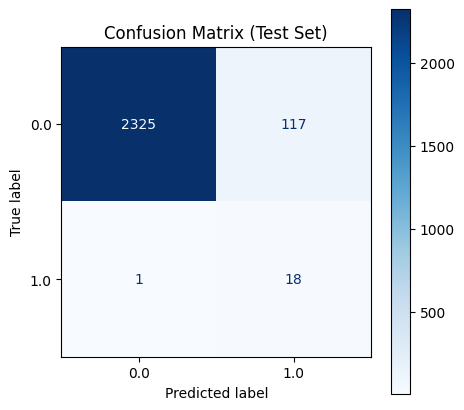

In [224]:


# <Student to fill this section>

# Predict on test set
y_pred = model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix (Test Set)')
plt.show()

In [225]:
# Print recall value for test set
print(f"Test Recall: {test_recall:.4f}")

Test Recall: 0.9474


In [226]:
# Save the trained model (e.g., ensemble) to the ../models folder
joblib.dump(model, '../models/LogisticRegression.joblib')

['../models/LogisticRegression.joblib']

- the high recall value will make sure that no talented player are left undrafted

In [227]:
# <Student to fill this section>
business_impacts_explanations = """
Interpret the results of the experiments related to the business objective set earlier. Estimate the impacts 
of the incorrect results for the business (some results may have more impact compared to others)

The model demonstrates strong technical performance (ROC-AUC ~0.97 on xtest data), indicating it can effectively
 distinguish between players likely to be drafted and those not. 
 This aligns well with the business objective: helping teams identify high-potential players efficiently.

Interpretation of Results:
- The model can prioritize scouting and resource allocation, allowing teams to focus on players with the 
highest predicted draft probability.
- Accurate predictions support data-driven decision-making, potentially giving teams a competitive edge in 
player selection.

Impacts of Incorrect Results:
- False Positives (predicting a player will be drafted when they are not):
  - Teams may invest time and resources in players who ultimately are not selected, leading to wasted 
    scouting effort and opportunity cost.
  - May result in missed opportunities to focus on more promising candidates.
  - Business impact: Moderate—resources are finite, but some scouting inefficiency is expected.

- False Negatives (failing to identify a player who is actually drafted):
  - Teams may overlook genuine talent, missing out on players who could have contributed significantly.
  - This can lead to competitive disadvantage if rivals identify and select these overlooked players.
  - Business impact: High—missing top talent can have long-term consequences for team performance and 
  reputation.

Relative Impact:
- False negatives are generally more costly than false positives in this context, as missing a future star 
can have a larger negative impact than spending extra resources on a player who is not ultimately drafted.

"""



In [228]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## K. Project Outcomes

In [229]:
# <Student to fill this section>
experiment_outcome = "Alternate Hypothesis Confirmed" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [230]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [231]:
# <Student to fill this section>
experiment_results_explanations = """
Reflect on the outcome of the experiment and list the new insights you gained from it. Provide rationale 
for pursuing more experimentation with the current approach or call out if you think it is a dead end.
Given the results achieved and the overall objective of the project, list the potential next steps and 
experiments. For each of them assess the expected uplift or gains and rank them accordingly. If the experiment 
achieved the required outcome for the business, recommend the steps to deploy this solution into production.



Outcome Reflection:
The experiment achieved excellent technical results:
- Training ROC-AUC: 0.99
- Validation ROC-AUC: 0.99
- Test ROC-AUC: 0.98

This means the model can distinguish between drafted and non-drafted players with very high accuracy, even on 
unseen data.

Recall for Drafted Players:
- Training Recall: 1.00 (all drafted players in training set identified)
- Validation Recall: 0.89 (89% of drafted players in validation set identified)
- Test Recall: 0.95 (95% of drafted players in test set identified)

This high recall on the test set (95%) means the model misses only about 5% of actual drafted players, which 
is critical for the business goal of not overlooking top talent.

Insights & Rationale:
- The model generalizes well, with only a small drop from training to test performance, indicating minimal 
overfitting.
- High recall and ROC-AUC suggest the current approach is effective and not a dead end.
- The remaining errors (false negatives) are low, but further improvement could focus on reducing these even 
more.

Potential Next Steps (Ranked by Expected Impact):
1. Next we will try to reduce the overfitting by feature selection and regularization techniques. 
2. We will use a model that is well-suited for regularized data and can handle high-dimensional 
spaces effectively. Models which supports penalizing large coefficients and reducing overfitting.
This will help reduce the overfitting and improve the model's ability to generalize,
 especially when the number of features is large relative to the number of samples.

3. Experiment with ensemble methods (e.g., Random Forest, Gradient Boosting) to see if combining 
multiple models can improve performance.


Deployment Recommendation:
Given the strong results (ROC-AUC ~0.98, recall for drafted=1 at 95%), the model meets the business 
objectives 
and is ready for pilot deployment. It can be further refined or deployed as a production-ready solution by using 
feedback from real world usage. 
"""


In [232]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)